In [ ]:
# !wget https://huggingface.co/neZorinEgor/data/resolve/main/data.zip -O data.zip
# !unzip data.zip

In [6]:
import os
from copy import deepcopy


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchview import draw_graph
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cuda'


In [8]:
dataset = pd.read_csv("/home/zorinep/workdir/magnesis/data/datasets/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [9]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

In [10]:
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
clean_dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [11]:
df = clean_dataset.copy()
df['hour'] = df['datetime'].dt.hour
df['day_of_year'] = df['datetime'].dt.dayofyear
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
# Циклическое преобразование (sin/cos) для часов
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
# Циклическое преобразование для дня года
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
# Циклическое преобразование для дня недели
df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df = df.drop(columns=['hour', 'day_of_year', 'day_of_week', 'month'])

In [12]:
# oulu_df = pd.read_csv("/home/zorinep/workdir/magnesis/data/processed/oulu/oulu_1995_2018.csv", header=None, sep=";")
# oulu_df.columns = ["Timestamp", "CorrectedCountRate[cts/min]"]
# oulu_df["Timestamp"] = pd.to_datetime(oulu_df["Timestamp"])
# oulu_df["Timestamp"] = oulu_df["Timestamp"].dt.tz_localize(None)
# oulu_df.loc[
#     (oulu_df["CorrectedCountRate[cts/min]"] <= 5_000) | 
#     (oulu_df["CorrectedCountRate[cts/min]"] >= 7_000),
#     "CorrectedCountRate[cts/min]"
# ] = np.nan
# oulu_df =  oulu_df[oulu_df["Timestamp"] <= str(df["datetime"].max())]
# oulu_df["CorrectedCountRate[cts/min]"] = oulu_df["CorrectedCountRate[cts/min]"].interpolate("pchip")
# oulu_df = oulu_df.bfill()
# oulu_df.rename(columns={"Timestamp": "datetime"}, inplace=True)
# plt.figure(figsize=(16, 5))
# plt.plot(oulu_df["CorrectedCountRate[cts/min]"])
# plt.grid()
# plt.show()

In [199]:
# jung_df = pd.read_csv("/home/zorinep/workdir/magnesis/data/processed/jung/jung_1995_2018.csv", header=None, sep=";")
# jung_df.columns = ["datetime", "jung_flux"]
# jung_df.loc[
#     (jung_df["jung_flux"] <= 5_000) |
#     (jung_df["jung_flux"] >= 13_000),
#     "jung_flux"
# ] = np.nan
# jung_df["datetime"] = pd.to_datetime(jung_df["datetime"])
# jung_df =  jung_df[jung_df["datetime"] <= str(df["datetime"].max())]
# jung_df["jung_flux"] = jung_df["jung_flux"].interpolate("pchip")
# jung_df = jung_df.bfill()
# plt.figure(figsize=(16, 5))
# plt.plot(jung_df["jung_flux"])
# plt.grid()
# plt.show()

In [200]:
# tmp_df = pd.merge(
#     df,
#     oulu_df[["datetime", "CorrectedCountRate[cts/min]"]],
#     how="outer",
#     on="datetime"
# )
# merged_df = pd.merge(
#     tmp_df,
#     jung_df,
#     how="outer",
#     on="datetime"
# )
# merged_df[["CorrectedCountRate[cts/min]", "jung_flux"]] = merged_df[["CorrectedCountRate[cts/min]", "jung_flux"]].interpolate(method="pchip")
# merged_df = merged_df.bfill()
# merged_df.head()

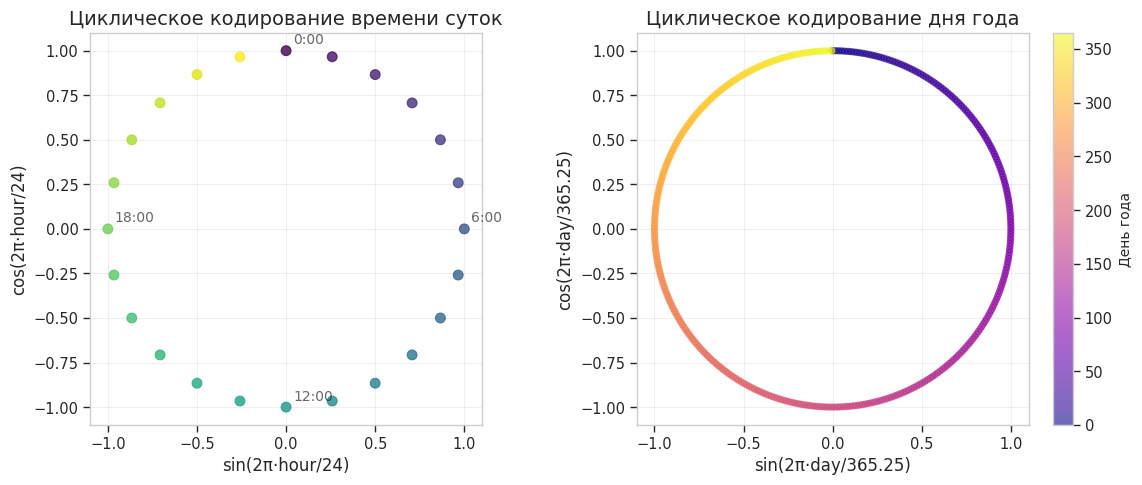

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Set2")  # Спокойная палитра

hours = np.linspace(0, 23, 24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

days = np.linspace(0, 365, 366)
day_sin = np.sin(2 * np.pi * days / 365.25)
day_cos = np.cos(2 * np.pi * days / 365.25)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(hour_sin, hour_cos, c=hours, cmap='viridis', s=50, alpha=0.8)
ax1.set_xlabel('sin(2π·hour/24)', fontsize=12)
ax1.set_ylabel('cos(2π·hour/24)', fontsize=12)
ax1.set_title('Циклическое кодирование времени суток', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Добавляем подписи для некоторых точек
for h in [0, 6, 12, 18]:
    idx = int(h)
    ax1.annotate(f'{h}:00', 
                (hour_sin[idx], hour_cos[idx]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=0.7)

# Дни года
ax2 = axes[1]
scatter = ax2.scatter(day_sin, day_cos, c=days, cmap='plasma', s=20, alpha=0.6)
ax2.set_xlabel('sin(2π·day/365.25)', fontsize=12)
ax2.set_ylabel('cos(2π·day/365.25)', fontsize=12)
ax2.set_title('Циклическое кодирование дня года', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Colorbar для второго графика
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('День года', fontsize=10)

plt.tight_layout()
plt.savefig('cyclic_encoding.png', dpi=300, bbox_inches='tight')
plt.show()

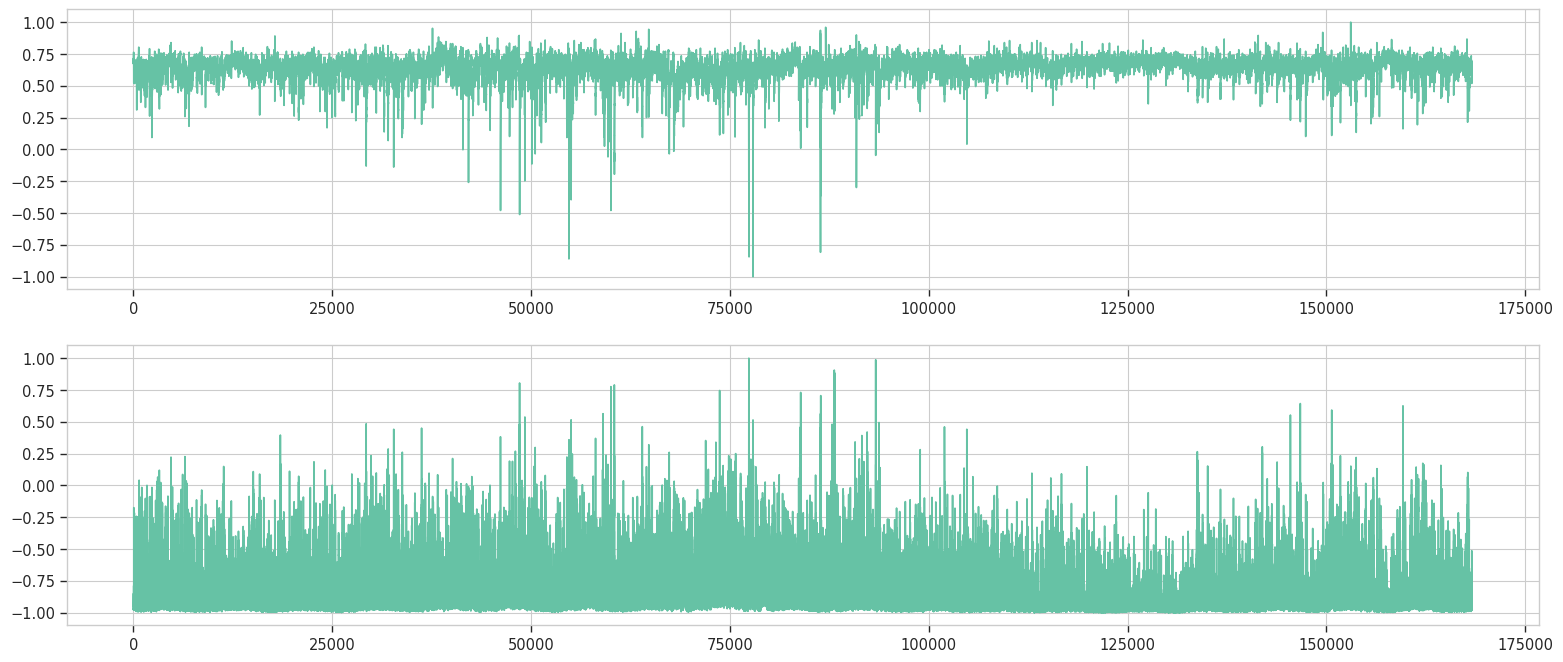

In [21]:
dataset_to_preprocess = df.copy()
# train/val 80/20
train_size = int(len(dataset_to_preprocess) * 0.8)
train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]
X_train = train.drop(columns=["datetime", "Dst"])
y_train = train[["Dst", "AE"]]
X_test = test.drop(columns=["datetime", "Dst"])
y_test = test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(19, 8))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

In [22]:
import joblib

joblib.dump(X_scaler, "GN_x_scaler.joblib")
joblib.dump(y_scaler, "GN_y_scaler.joblib")

['GN_y_scaler.joblib']

In [23]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        y_6h = y_window[-1, :]  
        return x_window, y_6h.unsqueeze(0)  # [1, 2]

In [24]:
def inference_on_loader_pipeline(model, loader, y_scaler, device='cuda', visualize: bool = False, title_prefix='', until=-1):
    dst_labels = []
    dst_preds = []
    ae_labels = []
    ae_preds = []

    with torch.no_grad():
        model.eval()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            dst_pred, ae_pred, _ = model(x)
            

            dst_pred = dst_pred.squeeze(1)  
            ae_pred = ae_pred.squeeze(1)   
            
            dst_true = y[:, 0, 0]  # [batch]
            ae_true = y[:, 0, 1]   # [batch]
            
            dst_preds.extend(dst_pred.cpu().numpy())
            ae_preds.extend(ae_pred.cpu().numpy())
            dst_labels.extend(dst_true.cpu().numpy())
            ae_labels.extend(ae_true.cpu().numpy())
    
    dst_preds = np.array(dst_preds)
    ae_preds = np.array(ae_preds)
    dst_labels = np.array(dst_labels)
    ae_labels = np.array(ae_labels)
    
    dst_pred_scaled = dst_preds.reshape(-1, 1)
    dst_true_scaled = dst_labels.reshape(-1, 1)
    ae_pred_scaled = ae_preds.reshape(-1, 1)
    ae_true_scaled = ae_labels.reshape(-1, 1)
    
    preds_combined = np.hstack([dst_pred_scaled, ae_pred_scaled])
    true_combined = np.hstack([dst_true_scaled, ae_true_scaled])
    
    preds_original = y_scaler.inverse_transform(preds_combined)
    true_original = y_scaler.inverse_transform(true_combined)
    
    dst_preds_orig = preds_original[:, 0][:until]
    ae_preds_orig = preds_original[:, 1][:until]
    dst_labels_orig = true_original[:, 0][:until]
    ae_labels_orig = true_original[:, 1][:until]
    
    # Метрики
    dst_rmse = np.sqrt(np.mean((dst_labels_orig - dst_preds_orig) ** 2))
    dst_mae = np.mean(np.abs(dst_labels_orig - dst_preds_orig))
    ae_rmse = np.sqrt(np.mean((ae_labels_orig - ae_preds_orig) ** 2))
    ae_mae = np.mean(np.abs(ae_labels_orig - ae_preds_orig))
    if visualize:
        _, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        axes[0].plot(dst_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        axes[0].plot(dst_preds_orig, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        axes[0].set_title(f'{title_prefix} Dst', fontsize=12)
        axes[0].set_xlabel('Временные шаги (часы)')
        axes[0].set_ylabel('Dst, nT')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].text(0.02, 0.95, f'RMSE = {dst_rmse:.2f} nT\nMAE = {dst_mae:.2f} nT', 
                    transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        axes[1].plot(ae_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        axes[1].plot(ae_preds_orig, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        axes[1].set_title(f'{title_prefix} AE', fontsize=12)
        axes[1].set_xlabel('Временные шаги (часы)')
        axes[1].set_ylabel('AE, nT')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].text(0.02, 0.95, f'RMSE = {ae_rmse:.2f} nT\nMAE = {ae_mae:.2f} nT', 
                    transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.suptitle(f'{title_prefix} Прогноз геомагнитных индексов', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print(f"{title_prefix} Результаты прогноза")
        print(f"Dst: RMSE = {dst_rmse:.2f} nT, MAE = {dst_mae:.2f} nT")
        print(f"AE:  RMSE = {ae_rmse:.2f} nT, MAE = {ae_mae:.2f} nT")
        
    return {
        'dst_rmse': dst_rmse,
        'dst_mae': dst_mae,
        'ae_rmse': ae_rmse,
        'ae_mae': ae_mae,
        'dst_preds': dst_preds_orig,
        'dst_labels': dst_labels_orig,
        'ae_preds': ae_preds_orig,
        'ae_labels': ae_labels_orig,
    }

In [25]:
def draw_dst_storm_prediction(inference_on_loader_result, storm_threshold, padding, min_duration, min_depth, above=False):
    def find_storm_periods(labels, threshold, padding, min_duration, min_depth, above=False):
        if above:
            mask = labels > threshold
        else:
            mask = labels < threshold  
        
        periods = []
        i = 0
        while i < len(mask):
            if mask[i]:
                start = i
                while i < len(mask) and mask[i]:
                    i += 1
                end = i - 1
                
                duration = end - start + 1
                if above:
                    max_val = np.max(labels[start:end+1])
                    depth = max_val - threshold
                else:
                    min_val = np.min(labels[start:end+1])
                    depth = threshold - min_val  # Глубина для Dst
                
                if duration >= min_duration and depth >= min_depth:
                    start_pad = max(0, start - padding)
                    periods.append((start_pad, end))
            else:
                i += 1
        return periods

    labels_full = np.array(inference_on_loader_result["dst_labels"])
    dst_periods = find_storm_periods(
        labels_full, 
        threshold=storm_threshold, 
        padding=padding,
        min_duration=min_duration,
        min_depth=min_depth,
        above=above  # Используем параметр функции
    )

    f1s = []
    for period in dst_periods:
        from_ = period[0]
        to = period[1]

        labels = np.array(inference_on_loader_result["dst_labels"][from_:to])
        preds = np.array(inference_on_loader_result["dst_preds"][from_:to])
        indices = np.arange(from_, to)
        
        # Для Dst: буря когда значения НИЖЕ порога
        storm_mask = labels < storm_threshold
        pred_storm_mask = preds < storm_threshold
        
        plt.figure(figsize=(18, 5))
        plt.plot(indices, labels, label='Истинные значения', color='#1f77b4', linewidth=1.5)
        plt.plot(indices, preds, label='Прогноз', color='#ff7f0e', linewidth=1.5)
        
        # Фактические бури
        storm_indices = indices[storm_mask]
        storm_values = labels[storm_mask]
        plt.scatter(storm_indices, storm_values, 
                    color='red', s=50, zorder=5, 
                    label=f'Фактическая буря (Dst < {storm_threshold} nT)', alpha=0.7)
        
        # Предсказанные бури
        pred_storm_indices = indices[pred_storm_mask]
        pred_storm_values = preds[pred_storm_mask]
        plt.scatter(pred_storm_indices, pred_storm_values, 
                    color='green', s=50, zorder=5, marker='s',
                    label=f'Модель предсказала бурю (Dst < {storm_threshold} nT)', alpha=0.7)
        
        plt.axhline(y=storm_threshold, color='red', linestyle='--', alpha=0.5, label=f'Порог {storm_threshold} nT')
        
        # Закрашиваем области бурь
        for i in range(len(storm_mask)):
            if storm_mask[i]:
                plt.axvspan(indices[i]-0.5, indices[i]+0.5, alpha=0.15, color='red', zorder=0)
        
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper left')
        plt.title(f'Dst: прогноз vs факт с выделением бурь (Dst < {storm_threshold} nT)')
        plt.xlabel('Временные шаги')
        plt.ylabel('Dst, nT')
        plt.tight_layout()
        plt.show()
        
        # Статистика
        print(f"=== Статистика по бурям (Dst < {storm_threshold} nT) ===")
        print(f"Всего моментов с бурей по факту: {np.sum(storm_mask)}")
        print(f"Всего моментов, когда модель предсказала бурю: {np.sum(pred_storm_mask)}")
        
        true_positives = np.sum(storm_mask & pred_storm_mask)
        false_positives = np.sum((~storm_mask) & pred_storm_mask)
        false_negatives = np.sum(storm_mask & (~pred_storm_mask))

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")

        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
            print(f"F1: {f1:.3f}")
            f1s.append(f1)
    if f1s:
        print(f"\nСредний F1 по всем бурям: {sum(f1s)/len(f1s):.3f}")
    else:
        print("\nНе найдено ни одного периода бури!")
    return f1s

In [26]:
def make_dataset(
    path,
    x_scaler,
    y_scaler,
    oulu_path=None,
    jung_path=None,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
    columns_to_drop=None
):
    dataset = pd.read_csv(path)
    dataset = dataset.drop(columns=["Unnamed: 0"])
    dataset['datetime'] = pd.to_datetime(
        dataset['Year'].astype(str) + '-' +
        dataset['Decimal Day'].astype(str) +
        ' ' +
        dataset['Hour'].astype(str),
        format='%Y-%j %H'
    )
    dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
    if columns_to_drop:
        dataset = dataset.drop(columns=columns_to_drop)
    cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
    dataset = dataset[cols]

    fill_values = {
        "Bz_GSM": 999.9,
        "By_GSM": 999.9,
        "Bx_GSE": 999.9,
        "Kp": 99,
        "f10.7": 999.9,
        "AL": 99999,
        "AU": 99999,
        "T_proton": 9999999.,
        "Np_density": 999.9,
        "V_plasma": 9999.,
        "V_Long_GSE": 999.9,
        "V_Lat_GSE": 999.9,
        "Dst": 99999,
        "AE": 9999,
    }
    for col in dataset.drop(columns=["datetime"]).columns:
        dataset[col] = dataset[col].replace(fill_values[col], np.nan)

    clean_dataset = dataset.copy()
    features = [i for i in clean_dataset.columns if i != "datetime"]
    clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
    df = clean_dataset.copy()
    df['hour'] = df['datetime'].dt.hour
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df = df.drop(columns=['hour', 'day_of_year', 'day_of_week', 'month'])
    if oulu_path is not None:
        oulu_df = pd.read_csv(oulu_path, header=None, sep=";")
        oulu_df.columns = ["Timestamp", "CorrectedCountRate[cts/min]"]
        oulu_df["Timestamp"] = pd.to_datetime(oulu_df["Timestamp"])
        oulu_df["Timestamp"] = oulu_df["Timestamp"].dt.tz_localize(None)
        oulu_df.loc[
            (oulu_df["CorrectedCountRate[cts/min]"] <= 5_000) | 
            (oulu_df["CorrectedCountRate[cts/min]"] >= 7_000),
            "CorrectedCountRate[cts/min]"
        ] = np.nan
        oulu_df =  oulu_df[oulu_df["Timestamp"] <= str(df["datetime"].max())]
        oulu_df.rename(columns={"Timestamp": "datetime"}, inplace=True)
        oulu_df["CorrectedCountRate[cts/min]"] = oulu_df["CorrectedCountRate[cts/min]"].interpolate("pchip")
        oulu_df = oulu_df.bfill()
        df = pd.merge(
            df,
            oulu_df[["datetime", "CorrectedCountRate[cts/min]"]],
            how="outer",
            on="datetime"
        )
    if jung_path is not None:
        jung_df = pd.read_csv(jung_path, header=None, sep=";")
        jung_df.columns = ["datetime", "jung_flux"]
        jung_df["jung_flux"] = jung_df["jung_flux"]/3
        jung_df.loc[
            (jung_df["jung_flux"] <= 5_000) |
            (jung_df["jung_flux"] >= 13_000),
            "jung_flux"
        ] = np.nan
        jung_df["datetime"] = pd.to_datetime(jung_df["datetime"])
        jung_df =  jung_df[jung_df["datetime"] <= str(df["datetime"].max())]
        jung_df["jung_flux"] = jung_df["jung_flux"].interpolate("pchip")
        jung_df = jung_df.bfill()
        df = pd.merge(
            df,
            jung_df[["datetime", "jung_flux"]],
            how="outer",
            on="datetime"
        )

    dataset_to_preprocess = df.copy()

    X_test, y_test = dataset_to_preprocess.drop(columns=["datetime", "Dst"]), dataset_to_preprocess[["Dst", "AE"]]

    X_test_scaled = x_scaler.transform(X_test)

    y_test_scaled = y_scaler.transform(y_test)
    test_dataset = GeomagneticDataset(
        X=X_test_scaled,
        y=y_test_scaled,
        X_window_size=X_window_size,
        y_window_size=y_window_size,
        stride=stride,
    )
    val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return val_loader

In [31]:
class GeomagneticModel(nn.Module):
    def __init__(
        self,
        n_features,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        ae_attention_heads,
    ):
        super().__init__()

        self.dst_lstm = nn.LSTM(
            n_features, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_lstm = nn.LSTM(
            n_features, lstm_hidden_size, lstm_num_layers,
            dropout=lstm_dropout, batch_first=True
        )

        self.dst_attention = nn.MultiheadAttention(
            lstm_hidden_size, dst_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        self.ae_attention = nn.MultiheadAttention(
            lstm_hidden_size, ae_attention_heads,
            dropout=lstm_dropout, batch_first=True
        )
        
        self.dst_attention_norm = nn.LayerNorm(lstm_hidden_size)
        self.ae_attention_norm = nn.LayerNorm(lstm_hidden_size)

        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size
        
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, 1),
        )

        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, 1),
        )

    def forward(self, x):
        dst_out, _ = self.dst_lstm(x)
        dst_query = dst_out[:, -1:, :]
        dst_attn_out, dst_attn_w = self.dst_attention(
            dst_query, dst_out, dst_out
        )
        dst_features = self.dst_attention_norm(
            dst_query.squeeze(1) + dst_attn_out.squeeze(1)
        )
        dst_features = self.dropout(dst_features)
        dst = self.dst_head(dst_features)

        ae_out, _ = self.ae_lstm(x)
        ae_query = ae_out[:, -1:, :]
        ae_attn_out, ae_attn_w = self.ae_attention(
            ae_query, ae_out, ae_out
        )
        ae_features = self.ae_attention_norm(
            ae_query.squeeze(1) + ae_attn_out.squeeze(1)
        )
        ae_features = self.dropout(ae_features)
        ae = self.ae_head(ae_features)

        return dst, ae, (dst_attn_w, ae_attn_w)

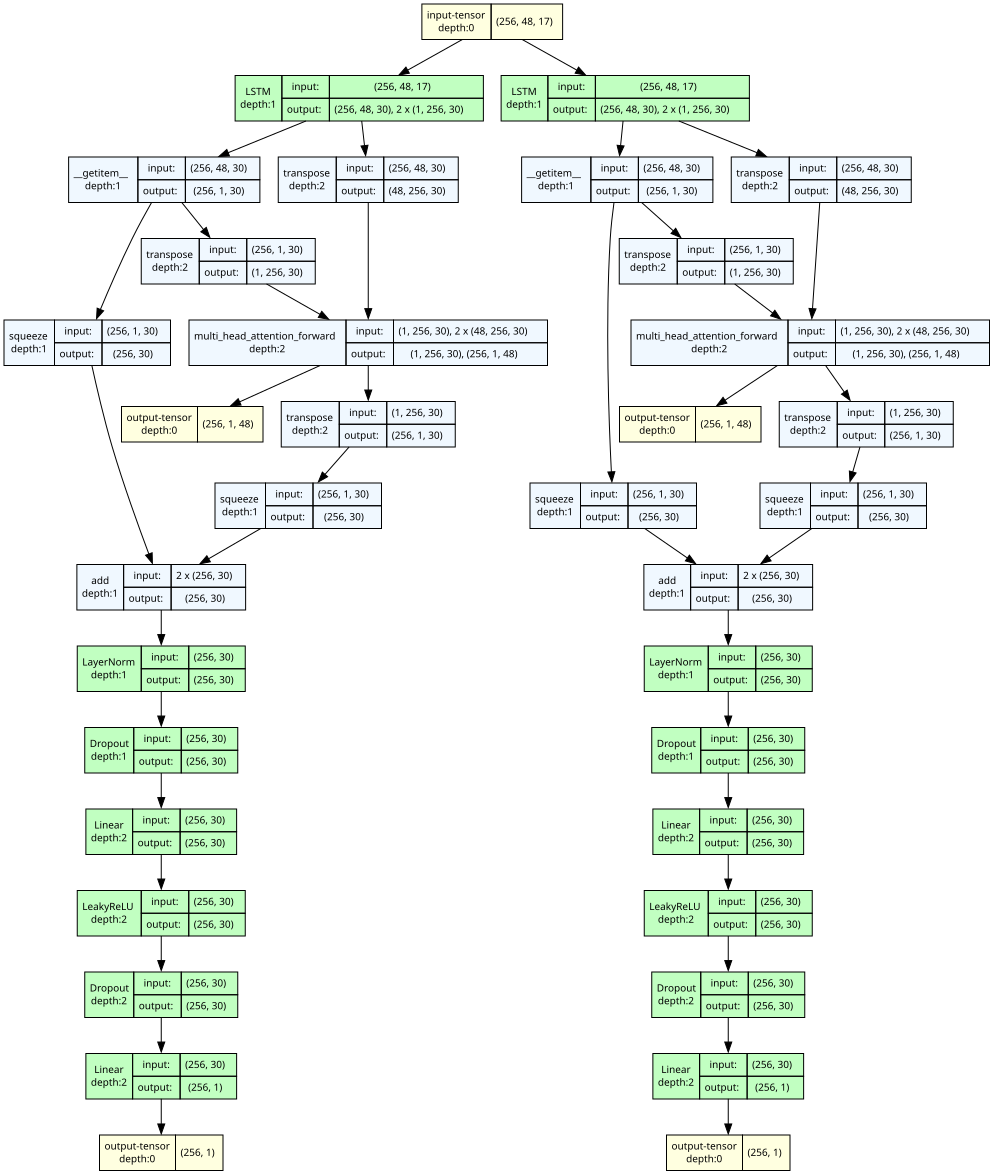

In [32]:
BATCH_SIZE = 256
N_FEATURES = 17
X_WINDOW_SIZE = 24*2

best_model_35 = GeomagneticModel(n_features=N_FEATURES, lstm_hidden_size=30, lstm_num_layers=1, lstm_dropout=0.0,  dst_attention_heads=10, ae_attention_heads=30).to(device)
graph = draw_graph(
    model=best_model_35,
    input_size=(BATCH_SIZE, X_WINDOW_SIZE, N_FEATURES)
)
graph.visual_graph

In [33]:
def train_geomagnetic_model(
    model,
    loss_fn,
    optimizer,
    lr_scheduler,
    epochs,
    train_loader,
    val_loader,
    y_scaler,
    patience,
    patience_delta=1e-4,
    stop_metric='loss',
    dst_loss_sigma=1.0,
    ae_loss_sigma=1.0,
    device="cuda",
    save_dir="./models"
):
    os.makedirs(save_dir, exist_ok=True)

    patience_counter = 0
    
    best_val_loss = float('inf')
    best_val_dst_rmse = float('inf')
    best_val_ae_rmse = float('inf')
    
    best_stop_metric = float('inf')
    
    best_epoch = 0
    best_dst_epoch = 0
    best_ae_epoch = 0

    history_train = {
        "lr": [],
        "dst_loss": [],
        "ae_loss": [],
        "summary_loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }
    history_val = {
        "loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }

    model.to(device)

    for e in range(epochs):
        model.train()
        train_progress = tqdm(train_loader)
        running_history = {
            "dst_loss": [],
            "ae_loss": [],
            "summary_loss": [],
            "ae": {"RMSE": [], "MAPE": [], "MAE": []},
            "dst": {"RMSE": [], "MAPE": [], "MAE": []}
        }

        for x, y in train_progress:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            # y имеет размер [batch, 1, 2]
            dst_y = y[:, 0, 0]  # [batch]
            ae_y = y[:, 0, 1]   # [batch]
            
            dst_y_pred, ae_y_pred, _ = model(x)
            dst_y_pred = dst_y_pred.squeeze(1)  # [batch]
            ae_y_pred = ae_y_pred.squeeze(1)    # [batch]

            dst_loss = loss_fn(dst_y_pred, dst_y)
            ae_loss = loss_fn(ae_y_pred, ae_y)
            loss = dst_loss * dst_loss_sigma + ae_loss_sigma * ae_loss

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                last_dst = x[:, -1, -2]
                last_ae = x[:, -1, -1]
                
                dst_pred_abs = last_dst + dst_y_pred
                ae_pred_abs = last_ae + ae_y_pred
                dst_true_abs = last_dst + dst_y
                ae_true_abs = last_ae + ae_y
                
                pred_data = np.stack([dst_pred_abs.detach().cpu().numpy(),
                                     ae_pred_abs.detach().cpu().numpy()], axis=1)
                label_data = np.stack([dst_true_abs.detach().cpu().numpy(),
                                      ae_true_abs.detach().cpu().numpy()], axis=1)
                
                pred_data = y_scaler.inverse_transform(pred_data)
                label_data = y_scaler.inverse_transform(label_data)

                dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
                ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
                dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
                ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
                dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
                ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

                running_history["dst"]["RMSE"].append(dst_rmse)
                running_history["ae"]["RMSE"].append(ae_rmse)
                running_history["dst"]["MAPE"].append(dst_mape)
                running_history["ae"]["MAPE"].append(ae_mape)
                running_history["dst"]["MAE"].append(dst_mae)
                running_history["ae"]["MAE"].append(ae_mae)
                running_history["dst_loss"].append(dst_loss.item())
                running_history["ae_loss"].append(ae_loss.item())
                running_history["summary_loss"].append(loss.item())

            train_progress.set_description(
                f"Epoch [{e+1:>3}/{epochs}] [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {loss.item():.4f}"
            )
        
        history_train["lr"].append(lr_scheduler.get_last_lr())
        history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
        history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
        history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
        history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
        history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
        history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
        history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
        history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
        history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))

        with torch.no_grad():
            model.eval()
            val_progress = tqdm(val_loader)
            running_val = {
                "loss": [],
                "ae": {"RMSE": [], "MAPE": [], "MAE": []},
                "dst": {"RMSE": [], "MAPE": [], "MAE": []}
            }

            for x, y in val_progress:
                x, y = x.to(device), y.to(device)
                
                dst_y = y[:, 0, 0]  # [batch]
                ae_y = y[:, 0, 1]   # [batch]
                
                dst_y_pred, ae_y_pred, _ = model(x)
                dst_y_pred = dst_y_pred.squeeze(1)  # [batch]
                ae_y_pred = ae_y_pred.squeeze(1)    # [batch]

                dst_loss = loss_fn(dst_y_pred, dst_y)
                ae_loss = loss_fn(ae_y_pred, ae_y)
                val_loss = dst_loss * dst_loss_sigma + ae_loss_sigma * ae_loss
                running_val["loss"].append(val_loss.item())

                last_dst = x[:, -1, -2]
                last_ae = x[:, -1, -1]
                
                dst_pred_abs = last_dst + dst_y_pred
                ae_pred_abs = last_ae + ae_y_pred
                dst_true_abs = last_dst + dst_y
                ae_true_abs = last_ae + ae_y
                
                pred_data = np.stack([dst_pred_abs.detach().cpu().numpy(),
                                     ae_pred_abs.detach().cpu().numpy()], axis=1)
                label_data = np.stack([dst_true_abs.detach().cpu().numpy(),
                                      ae_true_abs.detach().cpu().numpy()], axis=1)
                
                pred_data = y_scaler.inverse_transform(pred_data)
                label_data = y_scaler.inverse_transform(label_data)

                dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
                ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
                dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
                ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
                dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
                ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

                running_val["dst"]["RMSE"].append(dst_rmse)
                running_val["ae"]["RMSE"].append(ae_rmse)
                running_val["dst"]["MAPE"].append(dst_mape)
                running_val["ae"]["MAPE"].append(ae_mape)
                running_val["dst"]["MAE"].append(dst_mae)
                running_val["ae"]["MAE"].append(ae_mae)

                val_progress.set_description(
                    f"Epoch [{e+1:>3}/{epochs}] [VAL  ] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {val_loss.item():.4f}"
                )

            current_val_loss = np.mean(running_val["loss"])
            current_val_dst_rmse = np.mean(running_val["dst"]["RMSE"])
            current_val_ae_rmse = np.mean(running_val["ae"]["RMSE"])

            history_val["loss"].append(current_val_loss)
            history_val["dst"]["RMSE"].append(current_val_dst_rmse)
            history_val["ae"]["RMSE"].append(current_val_ae_rmse)
            history_val["dst"]["MAPE"].append(np.mean(running_val["dst"]["MAPE"]))
            history_val["ae"]["MAPE"].append(np.mean(running_val["ae"]["MAPE"]))
            history_val["dst"]["MAE"].append(np.mean(running_val["dst"]["MAE"]))
            history_val["ae"]["MAE"].append(np.mean(running_val["ae"]["MAE"]))

        lr_scheduler.step(metrics=current_val_loss)

        if current_val_loss < best_val_loss - patience_delta:
            best_val_loss = current_val_loss
            best_epoch = e + 1
            best_model_path = os.path.join(save_dir, f"best_model_loss_epoch_{best_epoch}_loss_{best_val_loss:.6f}.pt")
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model by loss! Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

        if current_val_dst_rmse < best_val_dst_rmse - (patience_delta * 0.1):
            best_val_dst_rmse = current_val_dst_rmse
            best_dst_epoch = e + 1
            best_dst_path = os.path.join(save_dir, f"best_model_dst_epoch_{best_dst_epoch}_rmse_{best_val_dst_rmse:.3f}.pt")
            torch.save(model.state_dict(), best_dst_path)
            print(f"New best model by DST RMSE! Epoch {best_dst_epoch}, DST RMSE: {best_val_dst_rmse:.3f}")

        if current_val_ae_rmse < best_val_ae_rmse - (patience_delta * 0.1):
            best_val_ae_rmse = current_val_ae_rmse
            best_ae_epoch = e + 1
            best_ae_path = os.path.join(save_dir, f"best_model_ae_epoch_{best_ae_epoch}_rmse_{best_val_ae_rmse:.3f}.pt")
            torch.save(model.state_dict(), best_ae_path)
            print(f"New best model by AE RMSE! Epoch {best_ae_epoch}, AE RMSE: {best_val_ae_rmse:.3f}")

        if stop_metric == 'loss':
            current_metric = current_val_loss
            metric_name = "Loss"
        elif stop_metric == 'dst_rmse':
            current_metric = current_val_dst_rmse
            metric_name = "DST RMSE"
        elif stop_metric == 'ae_rmse':
            current_metric = current_val_ae_rmse
            metric_name = "AE RMSE"
        elif stop_metric == 'combined':
            if e == 0:
                norm_loss = current_val_loss
                norm_dst = current_val_dst_rmse
                norm_ae = current_val_ae_rmse
            else:
                norm_loss = current_val_loss / history_val["loss"][0]
                norm_dst = current_val_dst_rmse / history_val["dst"]["RMSE"][0]
                norm_ae = current_val_ae_rmse / history_val["ae"]["RMSE"][0]
            current_metric = norm_loss + norm_dst + norm_ae
            metric_name = "Combined (Loss + DST + AE)"
        else:
            raise ValueError(f"Unknown stop_metric: {stop_metric}")

        if current_metric < best_stop_metric - patience_delta:
            best_stop_metric = current_metric
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter > 0:
            print(f"Early stopping patience: {patience_counter}/{patience} (best {metric_name}: {best_stop_metric:.6f}, current: {current_metric:.6f})")

        if patience_counter >= patience:
            print(f"\n{'='*60}")
            print(f"EARLY STOPPING triggered at epoch {e+1}")
            print(f"Stopping metric: {metric_name}")
            print(f"Best {metric_name}: {best_stop_metric:.6f}")
            print(f"Current {metric_name}: {current_metric:.6f}")
            print(f"\nBest models:")
            print(f"  - Loss: epoch {best_epoch}, value: {best_val_loss:.6f}")
            print(f"  - DST RMSE: epoch {best_dst_epoch}, value: {best_val_dst_rmse:.3f}")
            print(f"  - AE RMSE: epoch {best_ae_epoch}, value: {best_val_ae_rmse:.3f}")
            print(f"{'='*60}")

            last_model_path = os.path.join(save_dir, "last_model.pt")
            torch.save(model.state_dict(), last_model_path)
            print(f"Last model saved to: {last_model_path}")
            break

    else:
        final_model_path = os.path.join(save_dir, "final_model.pt")
        torch.save(model.state_dict(), final_model_path)
        print(f"\nTraining completed! Final model saved to: {final_model_path}")
        print(f"Best model by loss at epoch {best_epoch} with val loss: {best_val_loss:.6f}")
        print(f"Best model by DST at epoch {best_dst_epoch} with RMSE: {best_val_dst_rmse:.3f}")
        print(f"Best model by AE at epoch {best_ae_epoch} with RMSE: {best_val_ae_rmse:.3f}")

    return model, history_train, history_val

In [34]:
BATCH_SIZE = 256
STRIDE = 1
X_WINDOW_SIZE = 24*2


loader_2019_2025 = make_dataset(
    path="/home/zorinep/workdir/magnesis/data/row/omni/test/data_2019_2025.csv",
    jung_path=None,
    oulu_path=None,
    # jung_path="/home/zorinep/workdir/magnesis/data/processed/jung/jung2025_scaled.csv",
    # oulu_path="/home/zorinep/workdir/magnesis/data/processed/oulu/oulu_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
    X_window_size=X_WINDOW_SIZE,
    y_window_size=6,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
)

In [35]:
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
INITIAL_LR = 1e-4
EPOCHS = 3000
PATIENCE_DELTA = 1e-3
PATIENCE = 10
LR_SCHEDULER_FACTOR = 0.7      
LR_SCHEDULER_PATIENCE = 10     
LR_SCHEDULER_THRESHOLD = 1e-4  
LR_SCHEDULER_COOLDOWN = 5    
LR_SCHEDULER_MIN_LR = 1e-6     

Y_WINDOW_SIZE = 6
net = GeomagneticModel(
    n_features=19,
    lstm_hidden_size=30,
    lstm_num_layers=1,
    lstm_dropout=0.0,
    dst_attention_heads=5,
    ae_attention_heads=15,
)
print(f"Кол-во весов: {sum([i.numel() for i in net.parameters()])}")
loss_fn = nn.HuberLoss(delta=0.2)
optimizer = optim.AdamW(net.parameters(), lr=INITIAL_LR, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    threshold=LR_SCHEDULER_THRESHOLD,
    cooldown=LR_SCHEDULER_COOLDOWN,
    min_lr=LR_SCHEDULER_MIN_LR,
)

X_WINDOW_SIZE = 24*2
BATHCH_SIZE = 256
STRIDE = 1

train_dataset = GeomagneticDataset(X=X_train_scaled, y=y_train_scaled, X_window_size=X_WINDOW_SIZE, y_window_size=Y_WINDOW_SIZE, stride=STRIDE)
test_dataset = GeomagneticDataset(X=X_test_scaled, y=y_test_scaled, X_window_size=X_WINDOW_SIZE, y_window_size=Y_WINDOW_SIZE, stride=STRIDE)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATHCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATHCH_SIZE, shuffle=True)

try:
    model, th, vh = train_geomagnetic_model(
        # model/train objects
        model=net,
        loss_fn=loss_fn,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        # data
        epochs=EPOCHS,
        train_loader=train_loader,
        val_loader=val_loader,
        y_scaler=y_scaler,
        # lmbda=None,
        # early stoping
        patience=PATIENCE,
        patience_delta=PATIENCE_DELTA,
        dst_loss_sigma=1.0,
        ae_loss_sigma=3.0,
        device="cuda",
        save_dir="./my_models3999",
        stop_metric="dst_rmse"
    )
except KeyboardInterrupt:
    print("Stop by KeyboardInterrupt")

Кол-во весов: 21722


Epoch [  1/3000] [TRAIN] dst-RMSE 16.571 ae-RMSE 165.716 Loss 0.0317: 100%|██████████| 658/658 [00:06<00:00, 97.30it/s] 
Epoch [  1/3000] [VAL  ] dst-RMSE 13.203 ae-RMSE 160.930 Loss 0.0274: 100%|██████████| 165/165 [00:00<00:00, 175.86it/s]


New best model by loss! Epoch 1, Val Loss: 0.028997
New best model by DST RMSE! Epoch 1, DST RMSE: 15.980
New best model by AE RMSE! Epoch 1, AE RMSE: 165.661


Epoch [  2/3000] [TRAIN] dst-RMSE 10.555 ae-RMSE 168.665 Loss 0.0264: 100%|██████████| 658/658 [00:05<00:00, 117.84it/s]
Epoch [  2/3000] [VAL  ] dst-RMSE 9.564 ae-RMSE 166.971 Loss 0.0291: 100%|██████████| 165/165 [00:00<00:00, 189.84it/s] 


New best model by loss! Epoch 2, Val Loss: 0.026116
New best model by DST RMSE! Epoch 2, DST RMSE: 12.734
New best model by AE RMSE! Epoch 2, AE RMSE: 158.978


...

Early stopping patience: 8/10 (best DST RMSE: 10.035486, current: 10.132219)


Epoch [ 37/3000] [TRAIN] dst-RMSE 8.791 ae-RMSE 105.092 Loss 0.0138: 100%|██████████| 658/658 [00:05<00:00, 120.90it/s] 
Epoch [ 37/3000] [VAL  ] dst-RMSE 9.041 ae-RMSE 149.474 Loss 0.0252: 100%|██████████| 165/165 [00:00<00:00, 191.45it/s] 


Early stopping patience: 9/10 (best DST RMSE: 10.035486, current: 10.090874)


Epoch [ 38/3000] [TRAIN] dst-RMSE 10.513 ae-RMSE 152.467 Loss 0.0257: 100%|██████████| 658/658 [00:05<00:00, 119.81it/s]
Epoch [ 38/3000] [VAL  ] dst-RMSE 8.614 ae-RMSE 137.396 Loss 0.0198: 100%|██████████| 165/165 [00:00<00:00, 191.61it/s] 


Early stopping patience: 10/10 (best DST RMSE: 10.035486, current: 10.081912)

EARLY STOPPING triggered at epoch 38
Stopping metric: DST RMSE
Best DST RMSE: 10.035486
Current DST RMSE: 10.081912

Best models:
  - Loss: epoch 20, value: 0.023881
  - DST RMSE: epoch 28, value: 10.035
  - AE RMSE: epoch 32, value: 151.634
Last model saved to: ./my_models33/last_model.pt


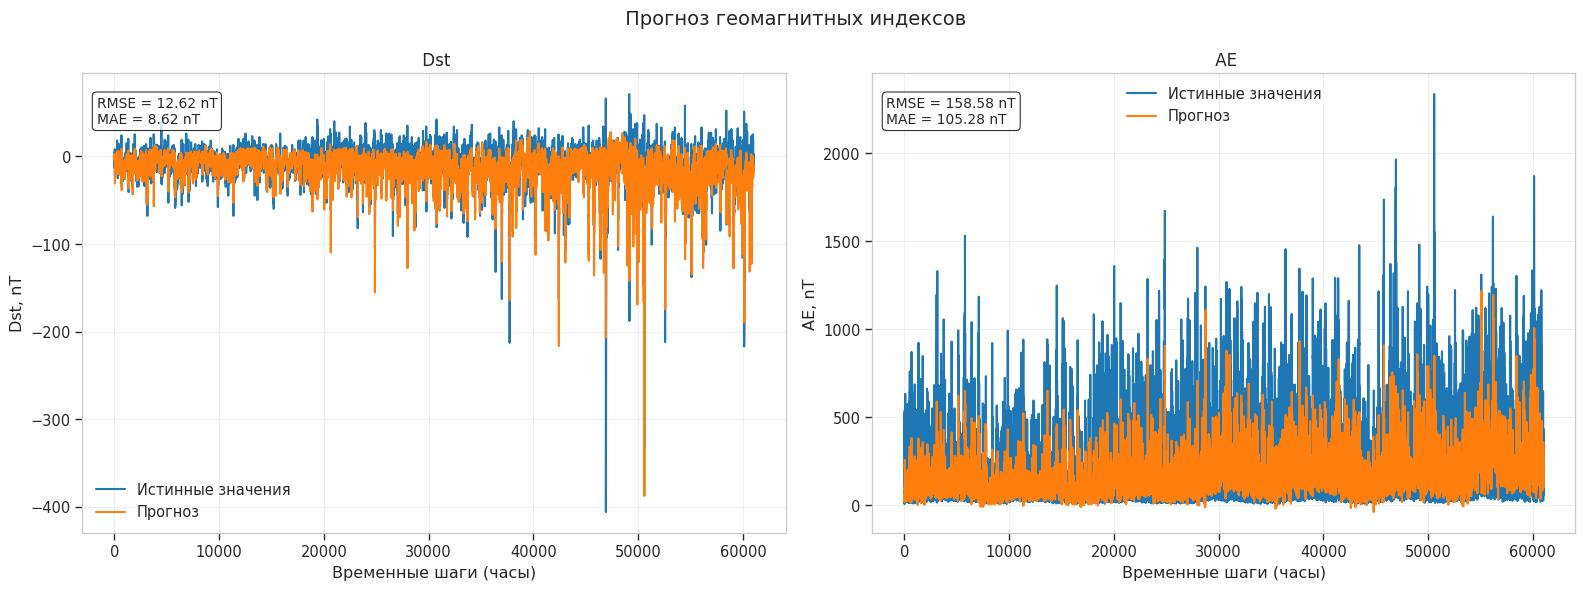

 Результаты прогноза
Dst: RMSE = 12.62 nT, MAE = 8.62 nT
AE:  RMSE = 158.58 nT, MAE = 105.28 nT


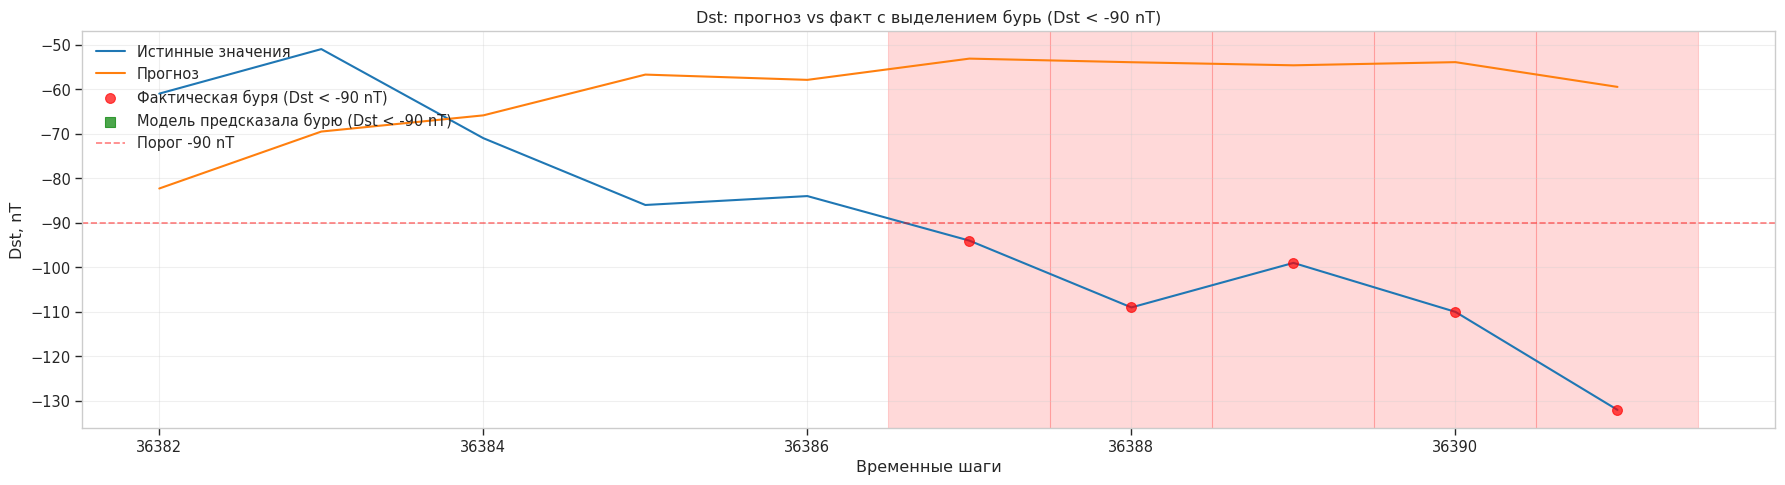

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


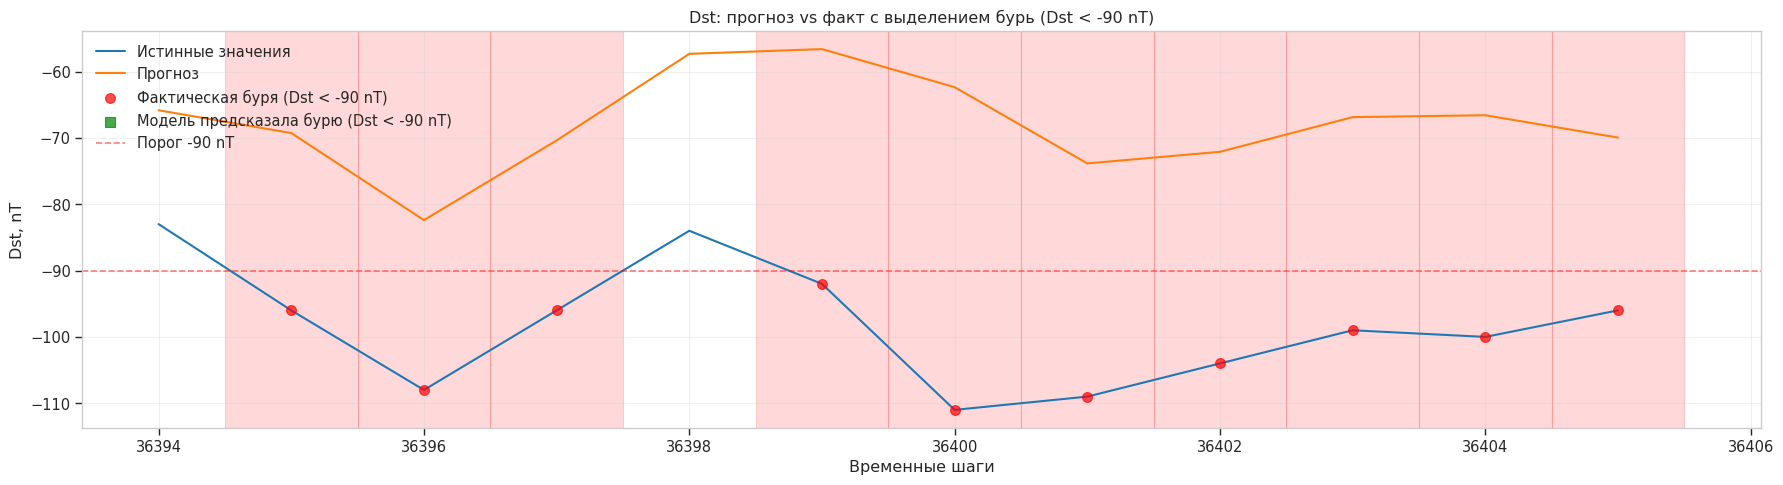

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


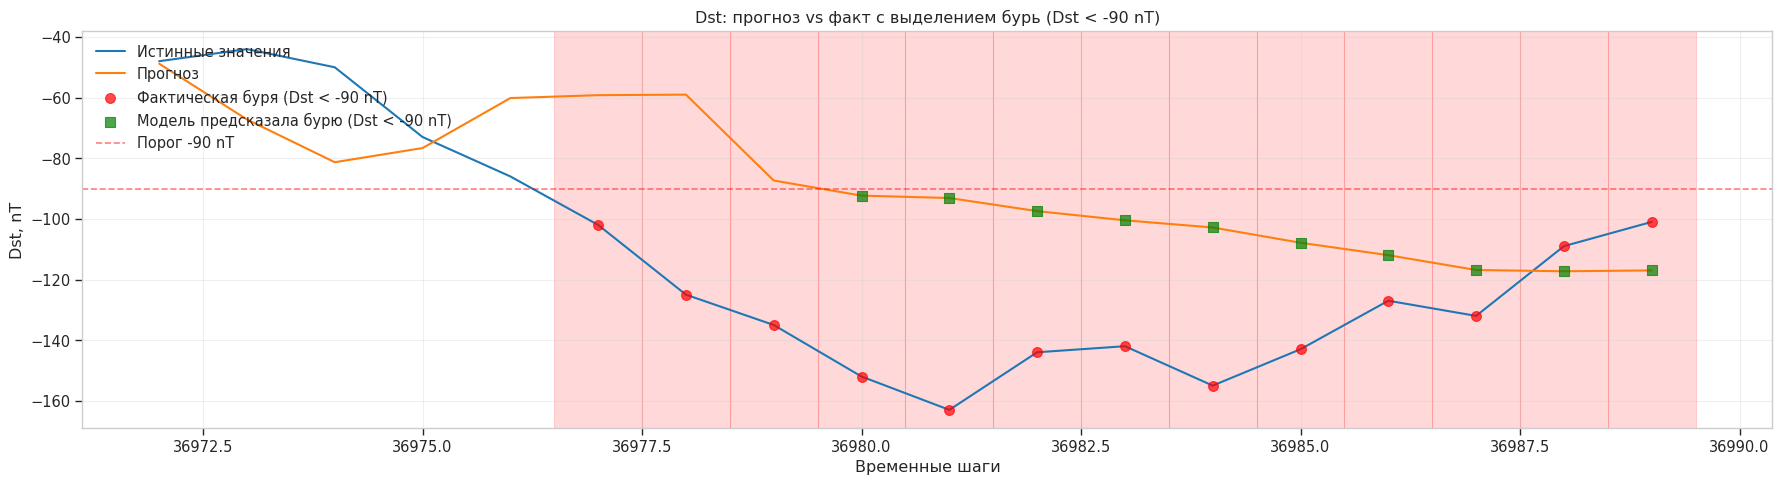

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 10
Precision: 1.000
Recall: 0.769
F1: 0.870


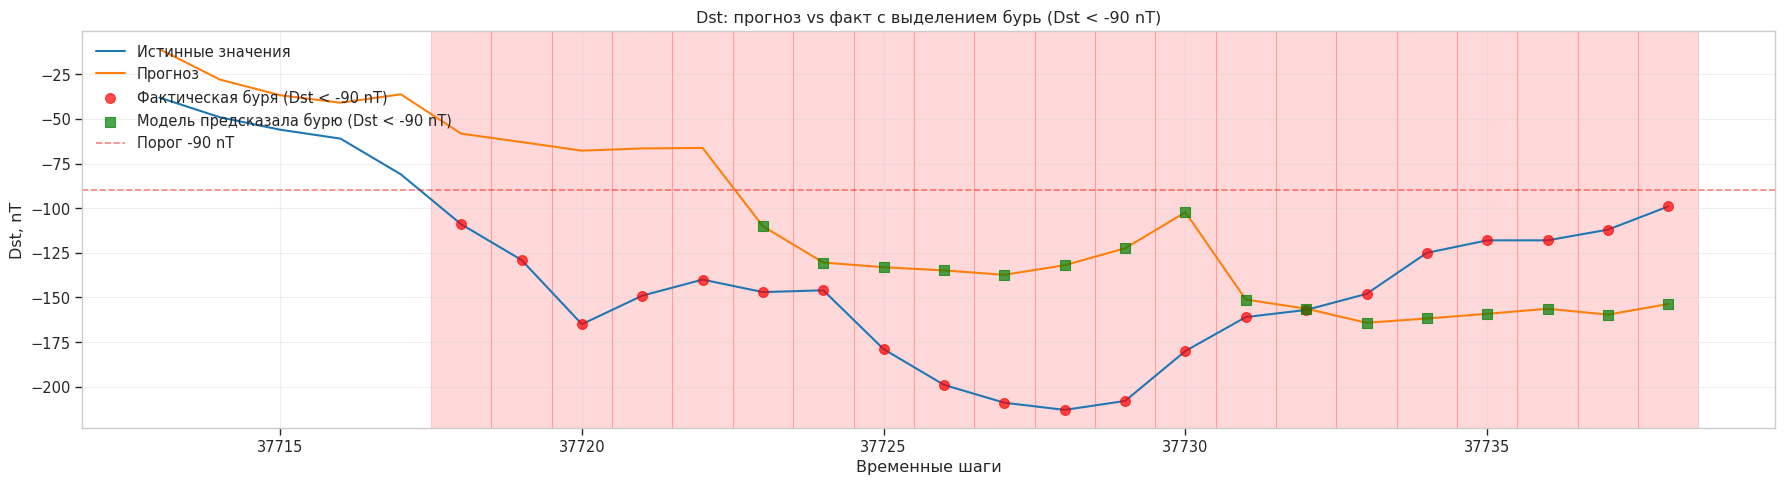

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 16
Precision: 1.000
Recall: 0.762
F1: 0.865


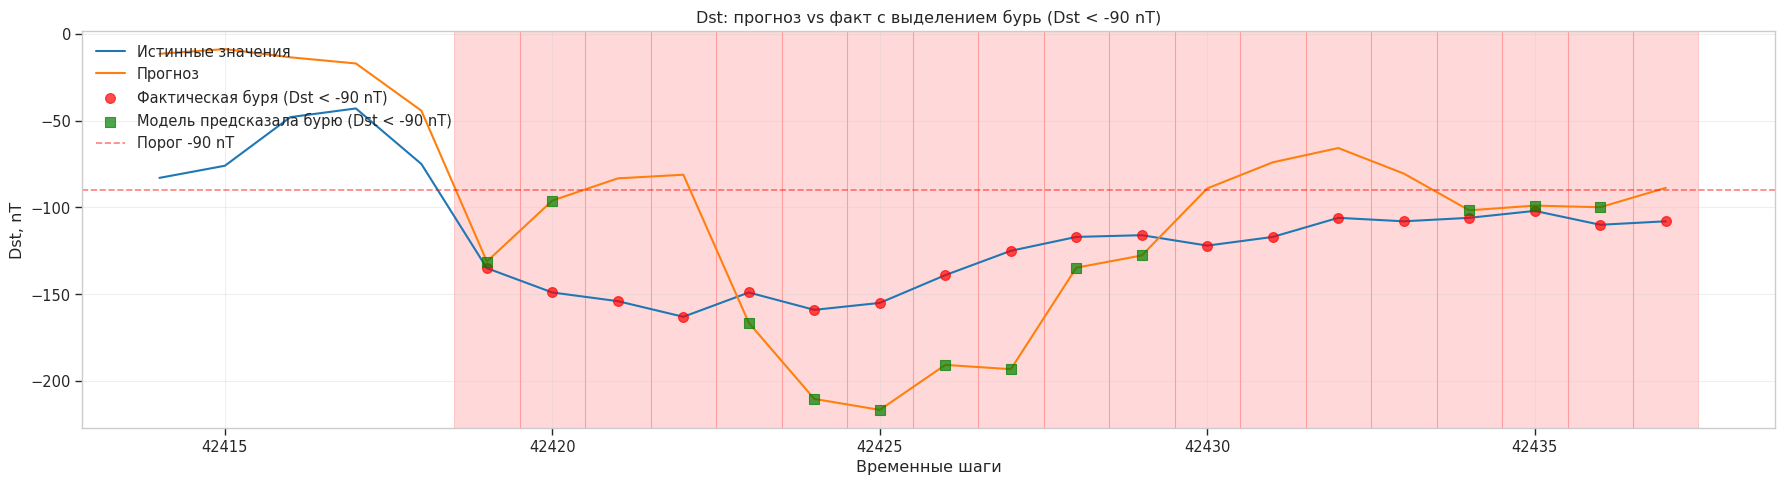

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 12
Precision: 1.000
Recall: 0.632
F1: 0.774


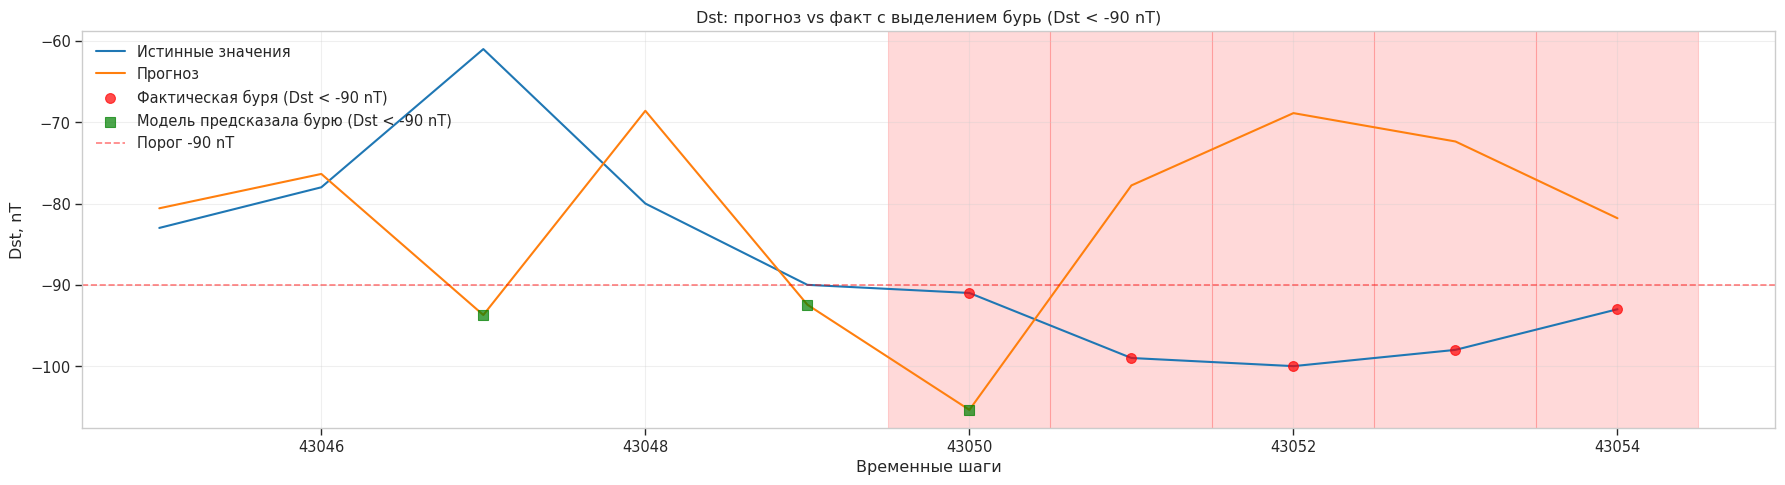

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 3
Precision: 0.333
Recall: 0.200
F1: 0.250


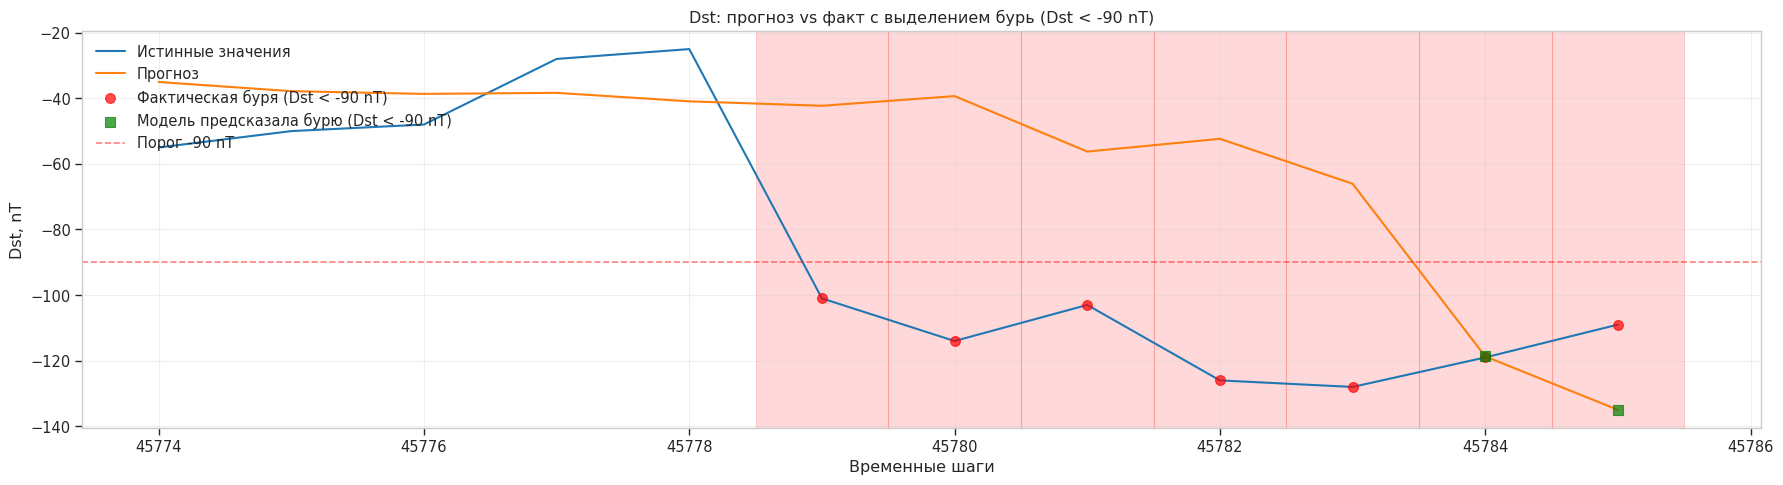

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.286
F1: 0.444


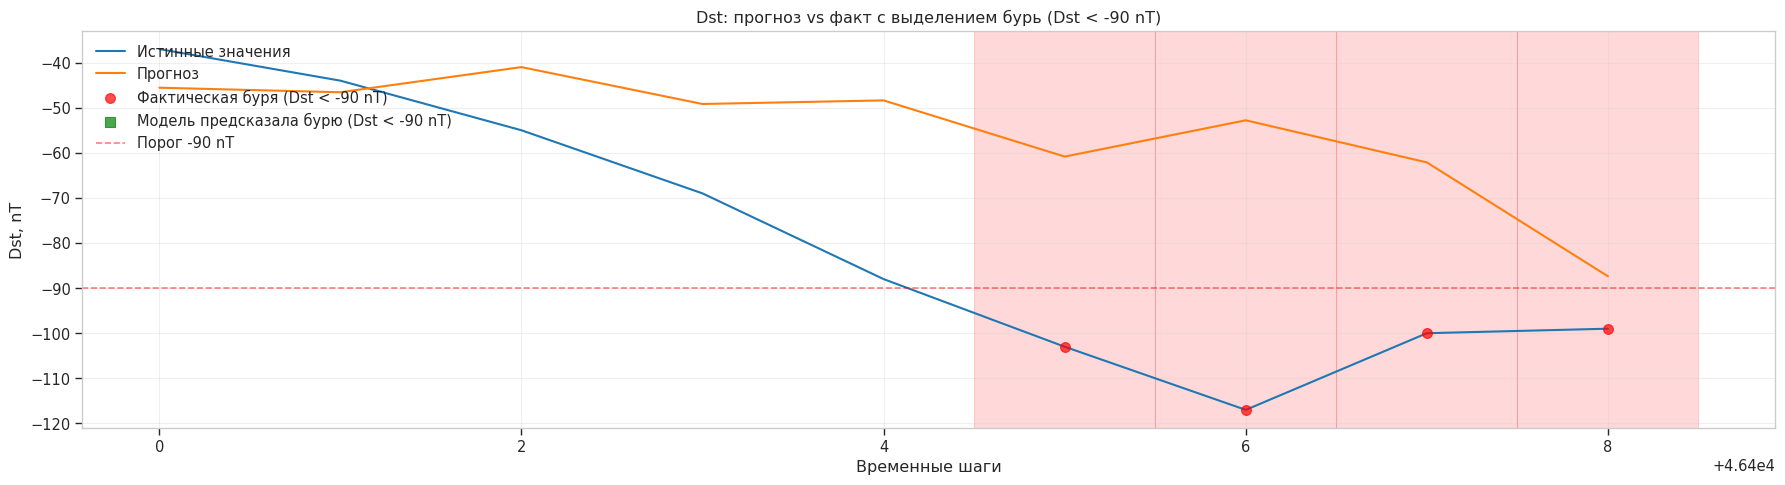

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 4
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


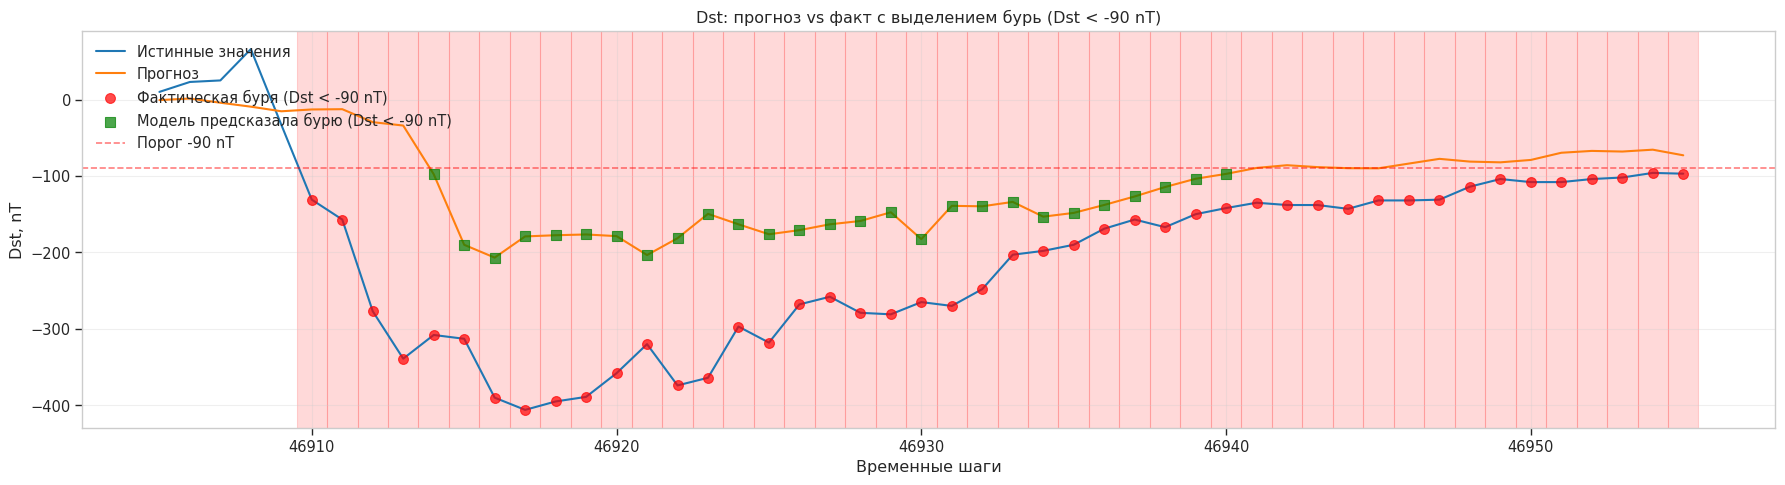

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 46
Всего моментов, когда модель предсказала бурю: 27
Precision: 1.000
Recall: 0.587
F1: 0.740


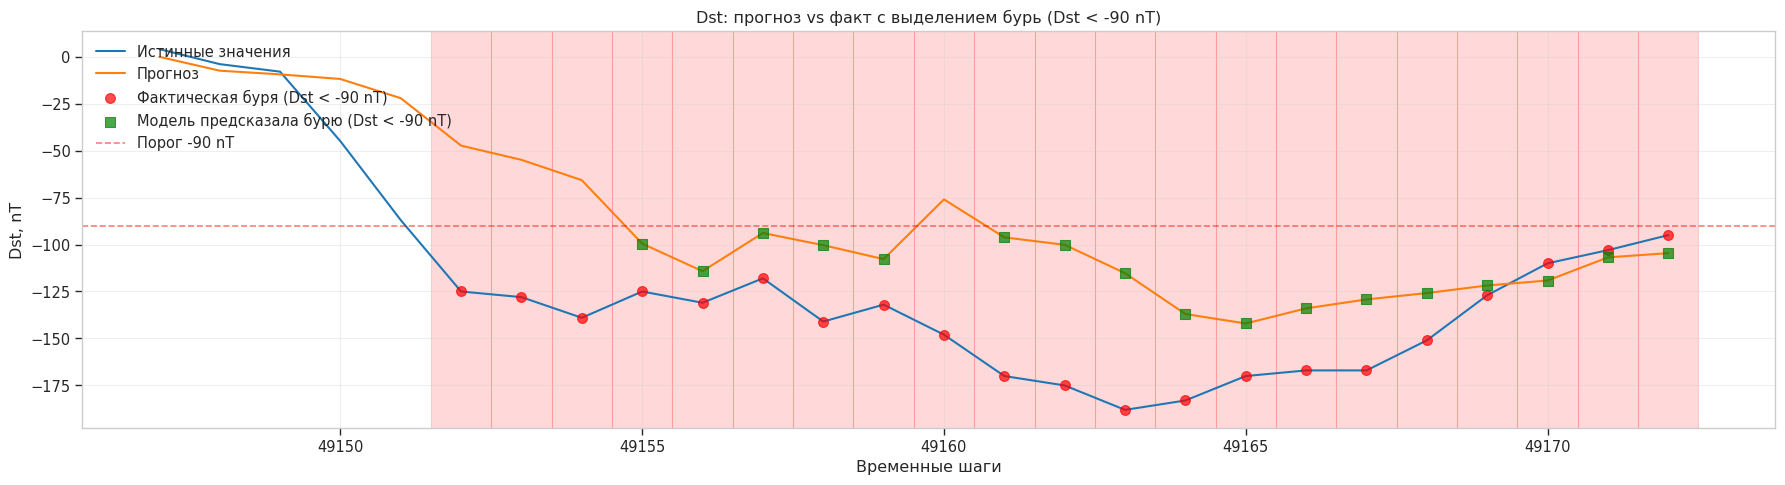

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 17
Precision: 1.000
Recall: 0.810
F1: 0.895


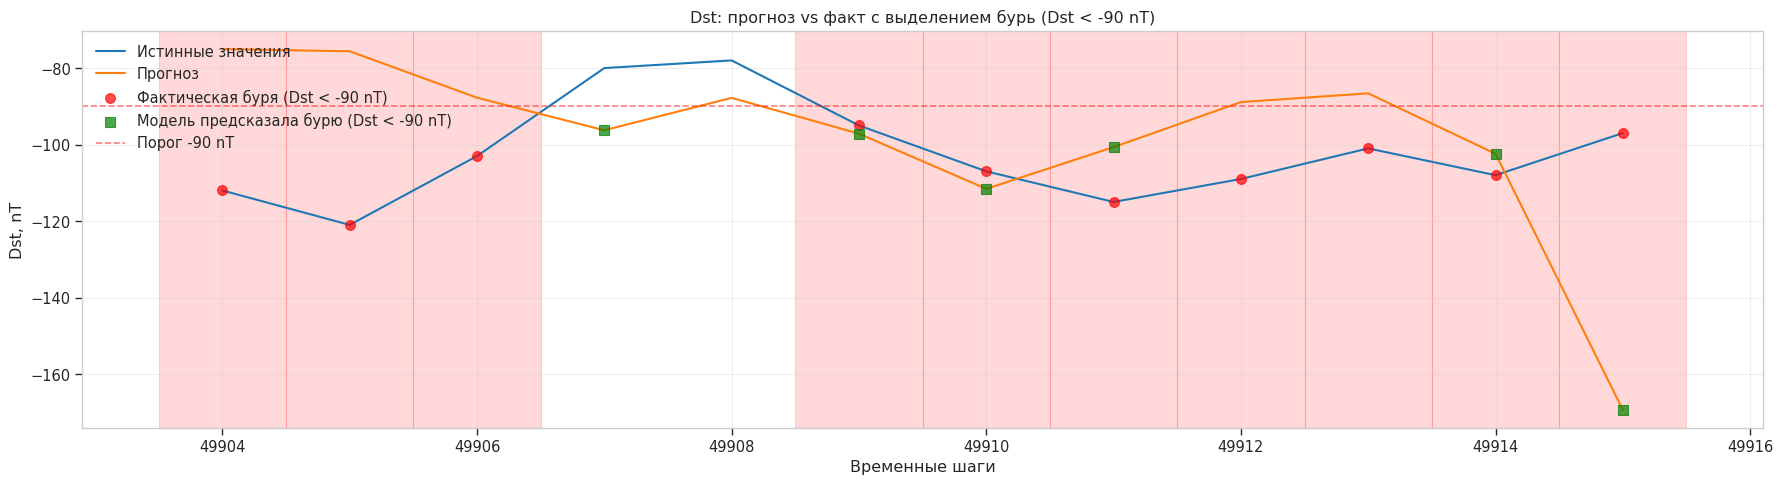

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 6
Precision: 0.833
Recall: 0.500
F1: 0.625


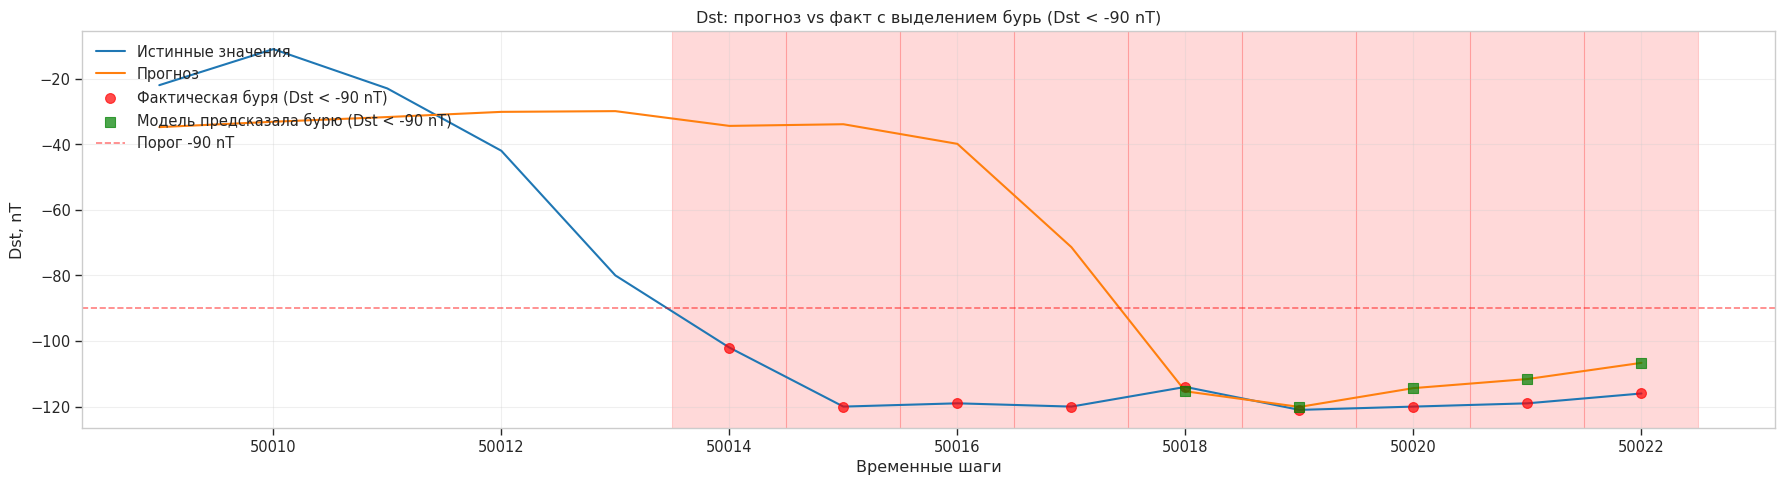

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 5
Precision: 1.000
Recall: 0.556
F1: 0.714


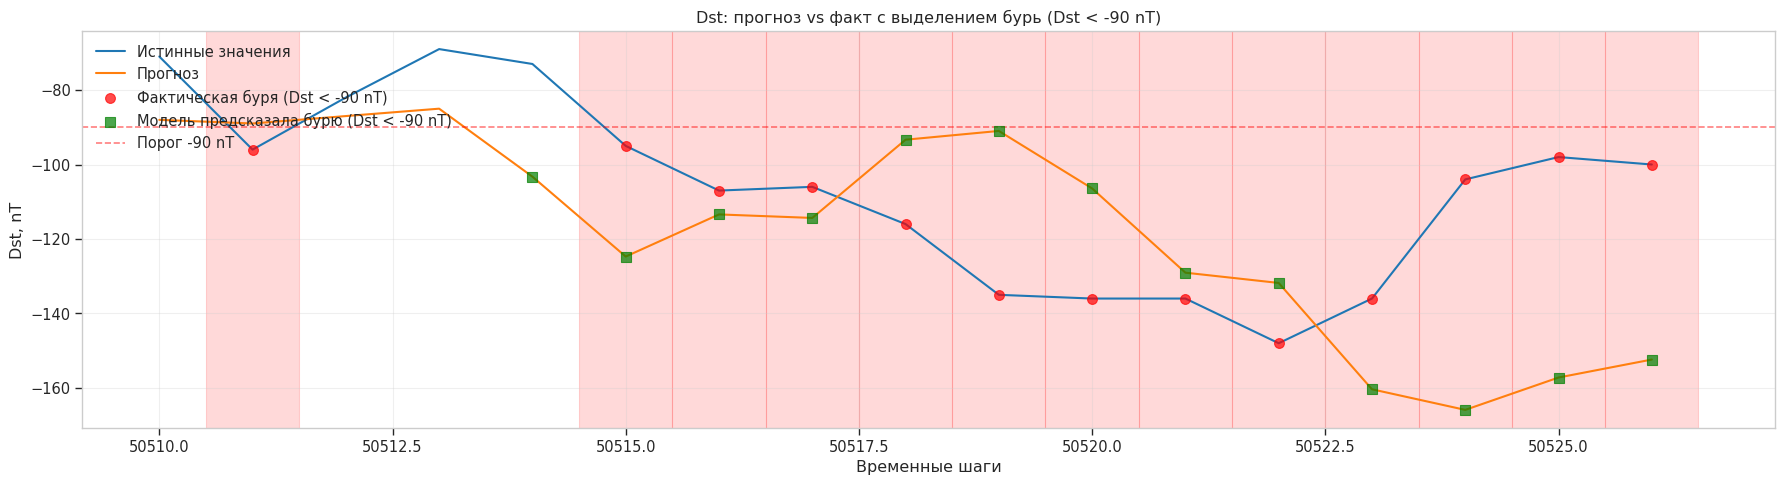

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 13
Precision: 0.923
Recall: 0.923
F1: 0.923


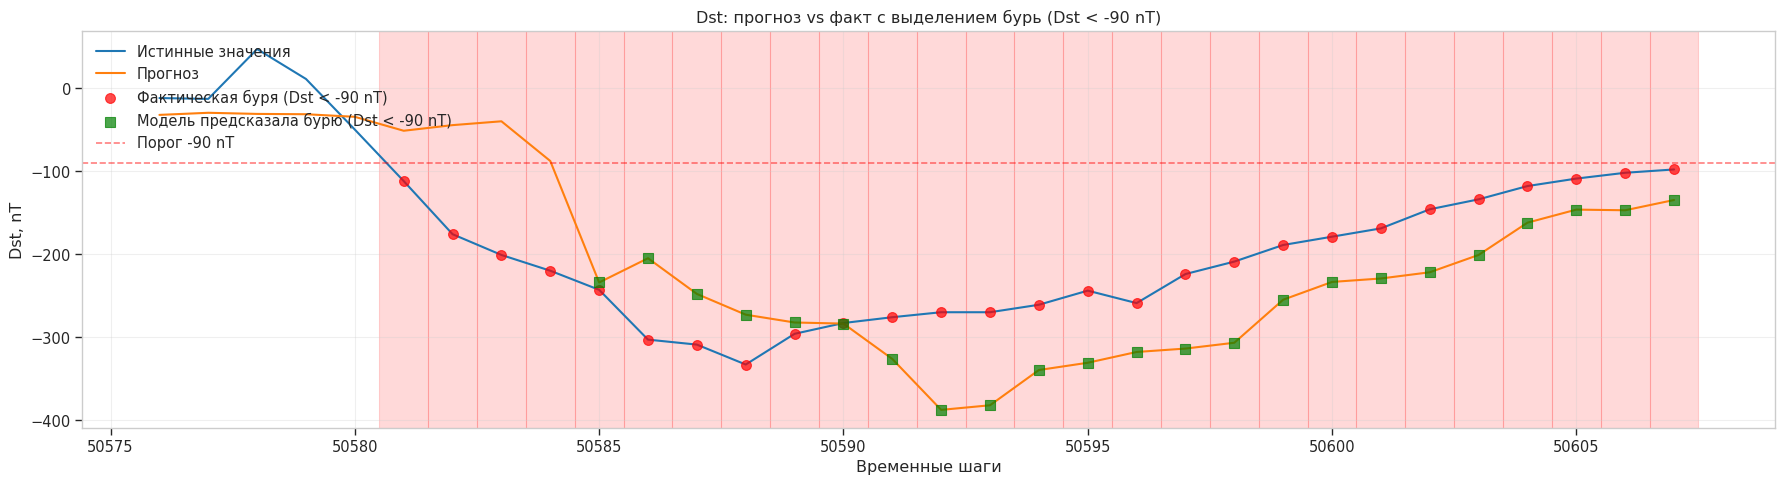

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 27
Всего моментов, когда модель предсказала бурю: 23
Precision: 1.000
Recall: 0.852
F1: 0.920


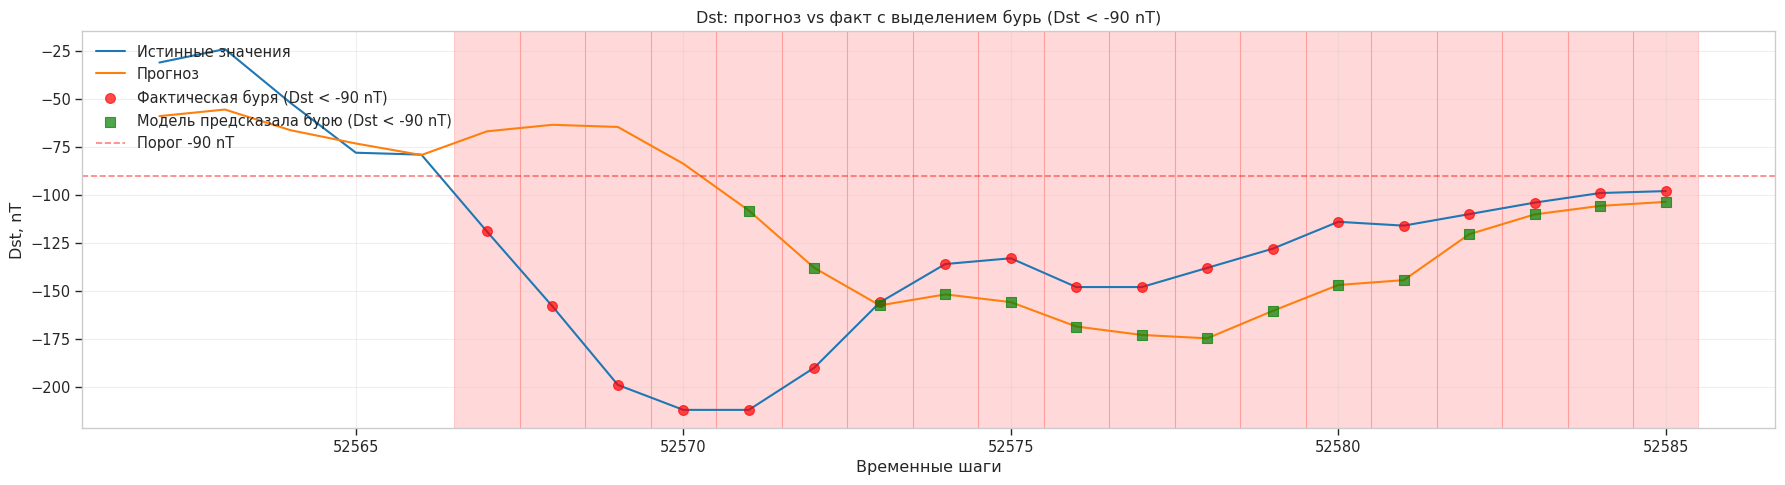

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 15
Precision: 1.000
Recall: 0.789
F1: 0.882


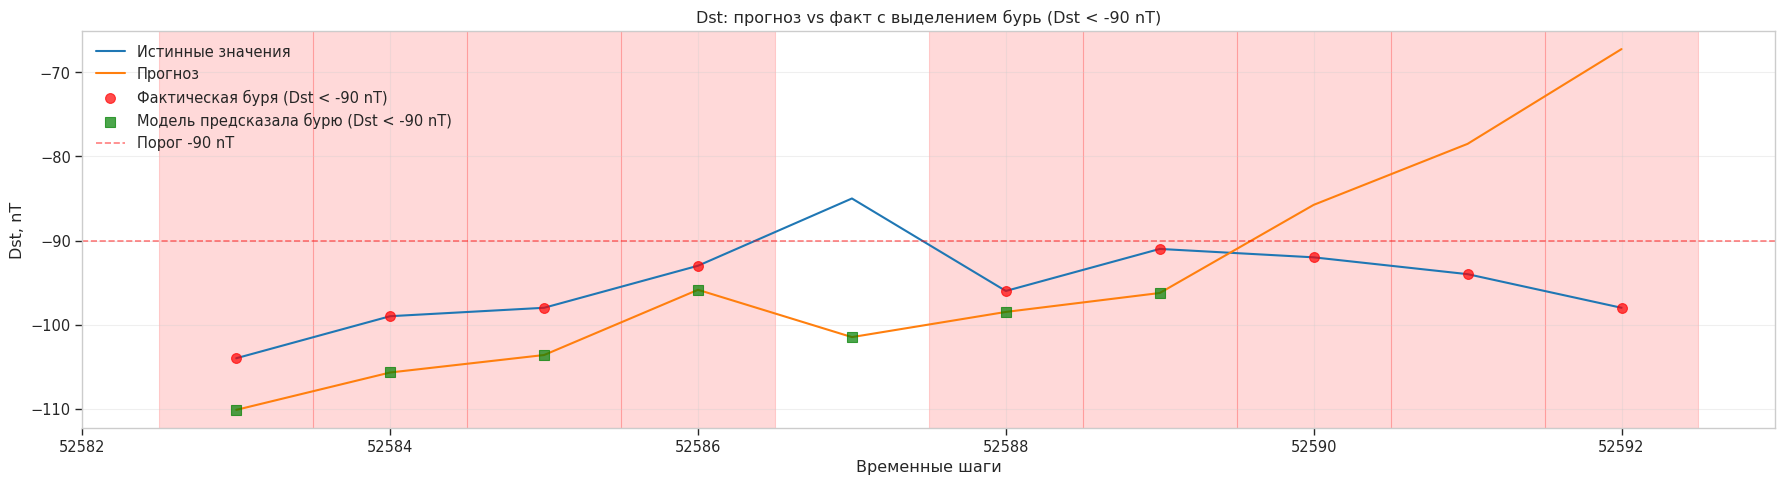

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 7
Precision: 0.857
Recall: 0.667
F1: 0.750


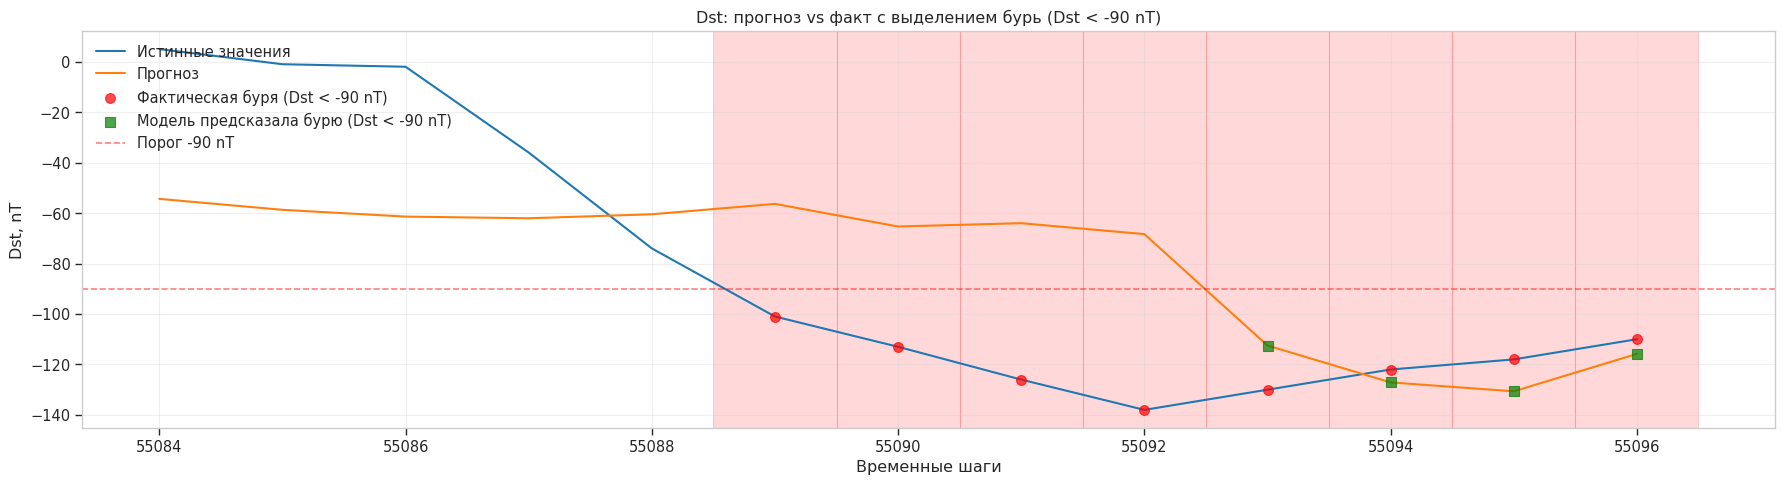

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 4
Precision: 1.000
Recall: 0.500
F1: 0.667


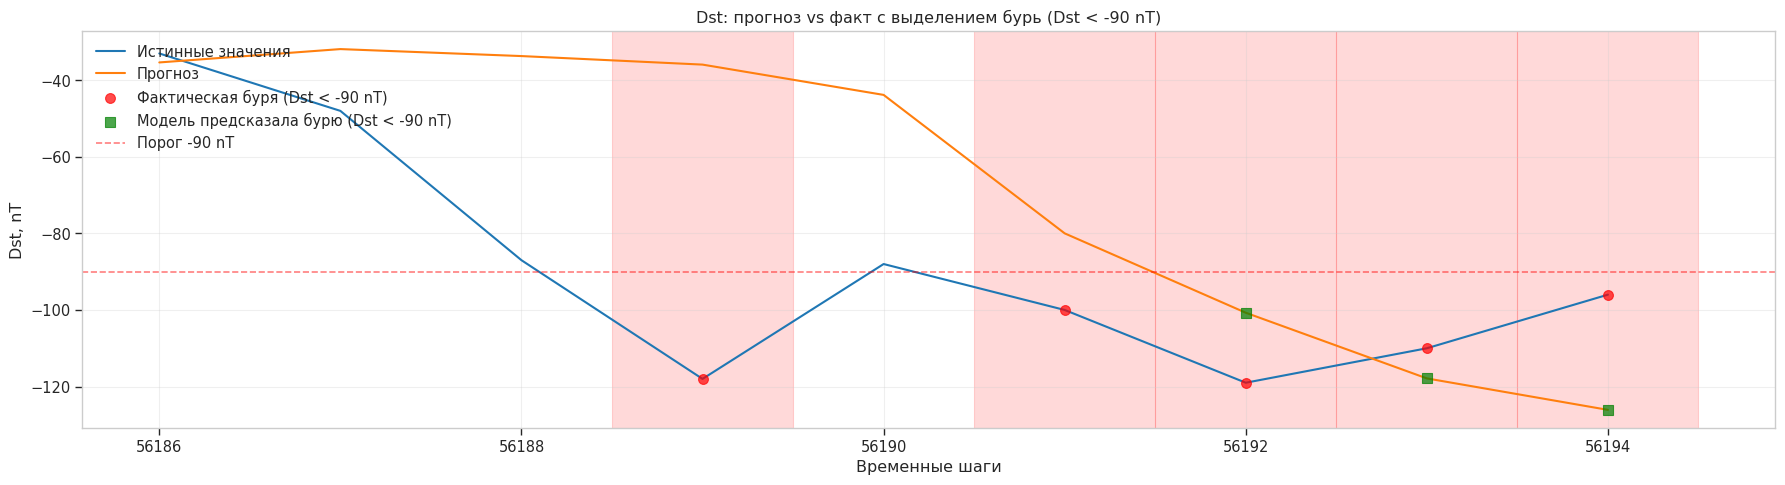

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 3
Precision: 1.000
Recall: 0.600
F1: 0.750


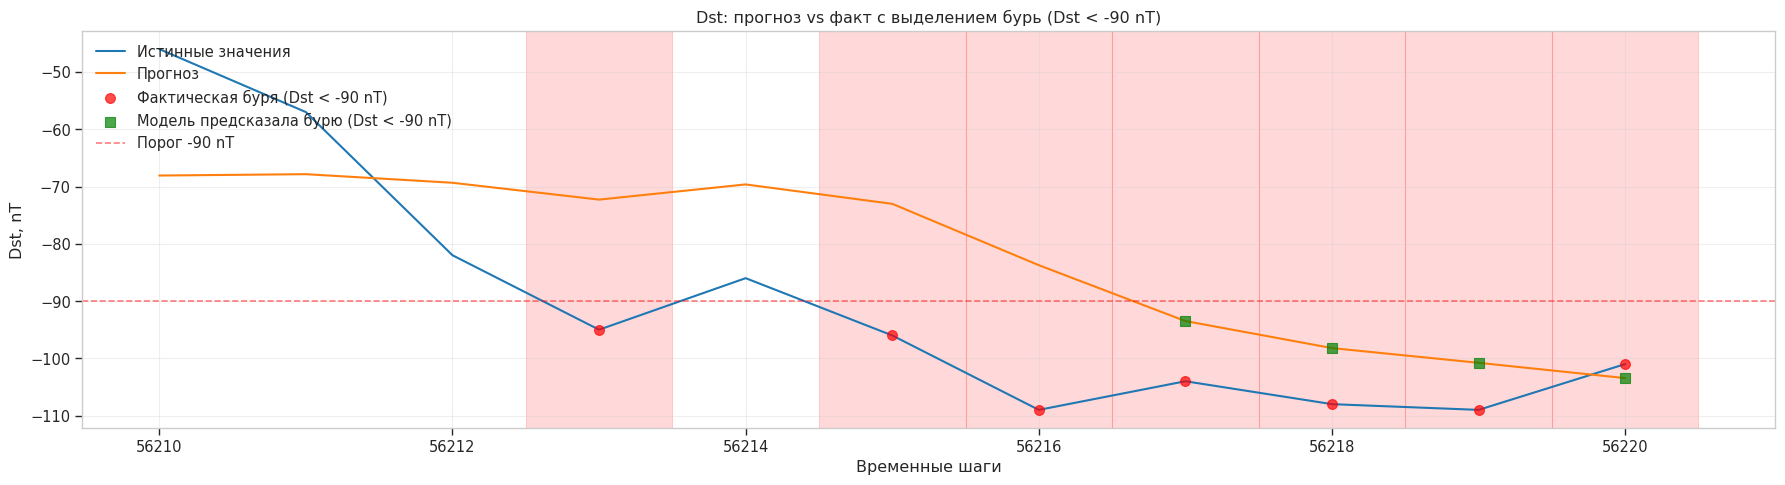

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 4
Precision: 1.000
Recall: 0.571
F1: 0.727


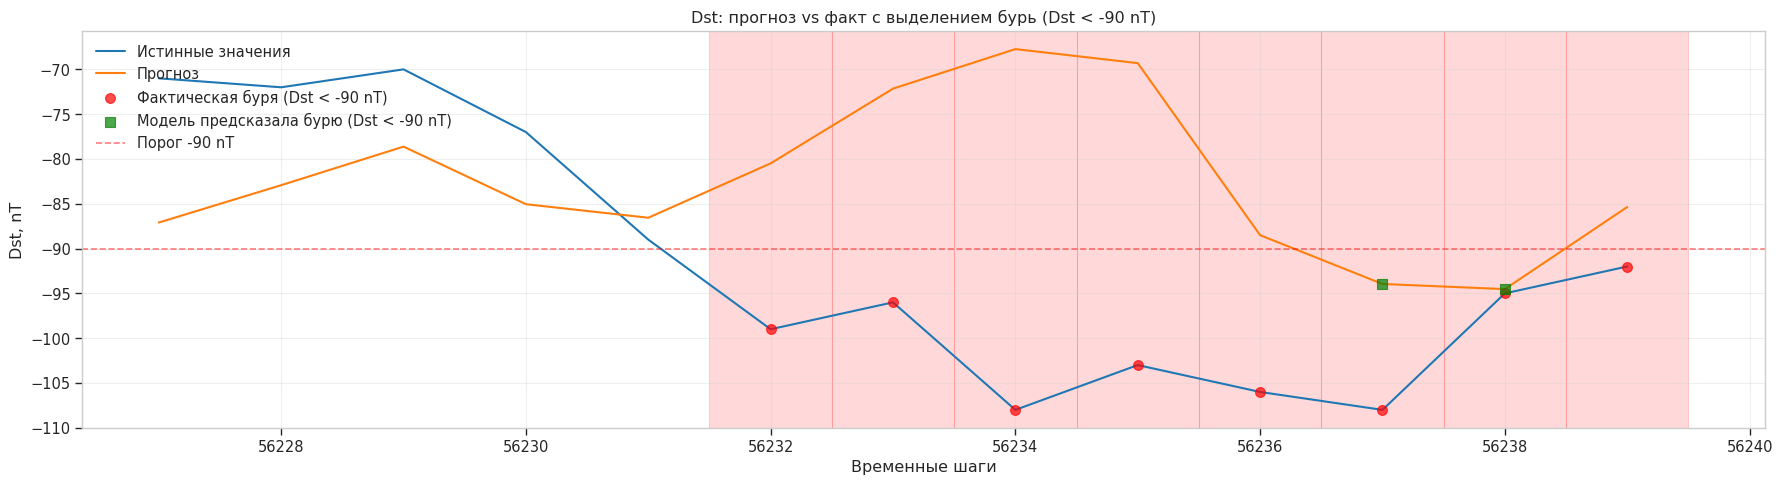

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.250
F1: 0.400


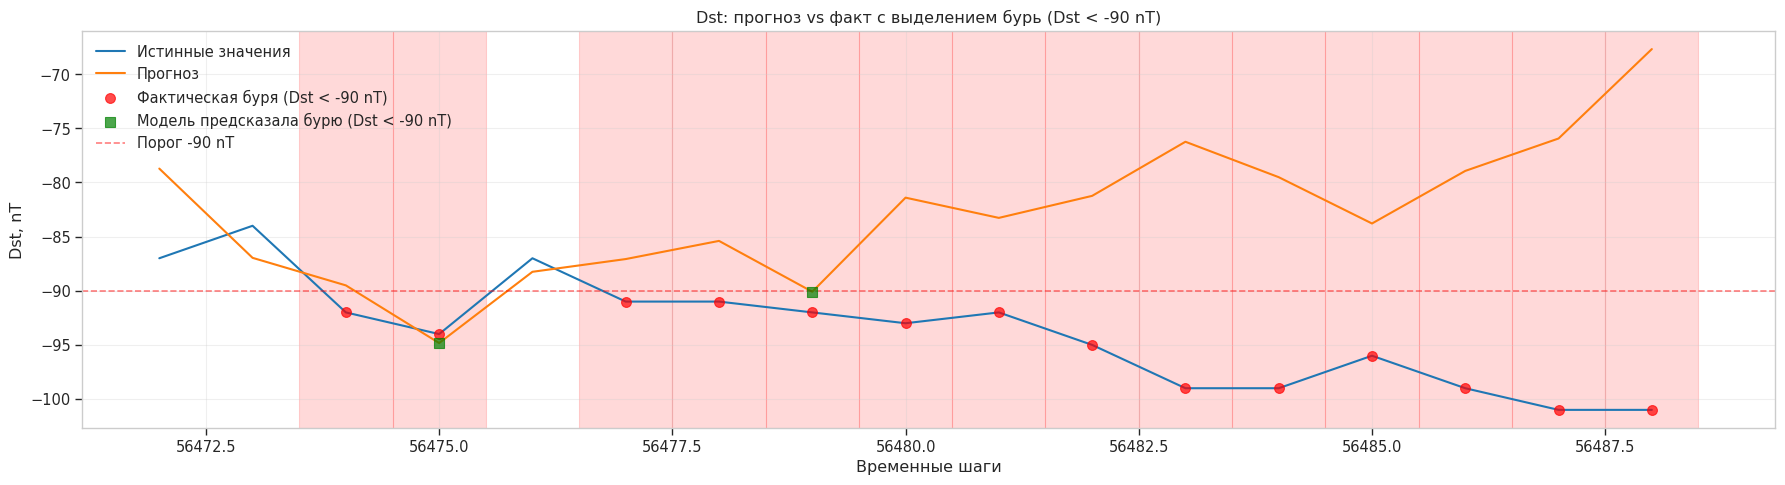

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 14
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.143
F1: 0.250


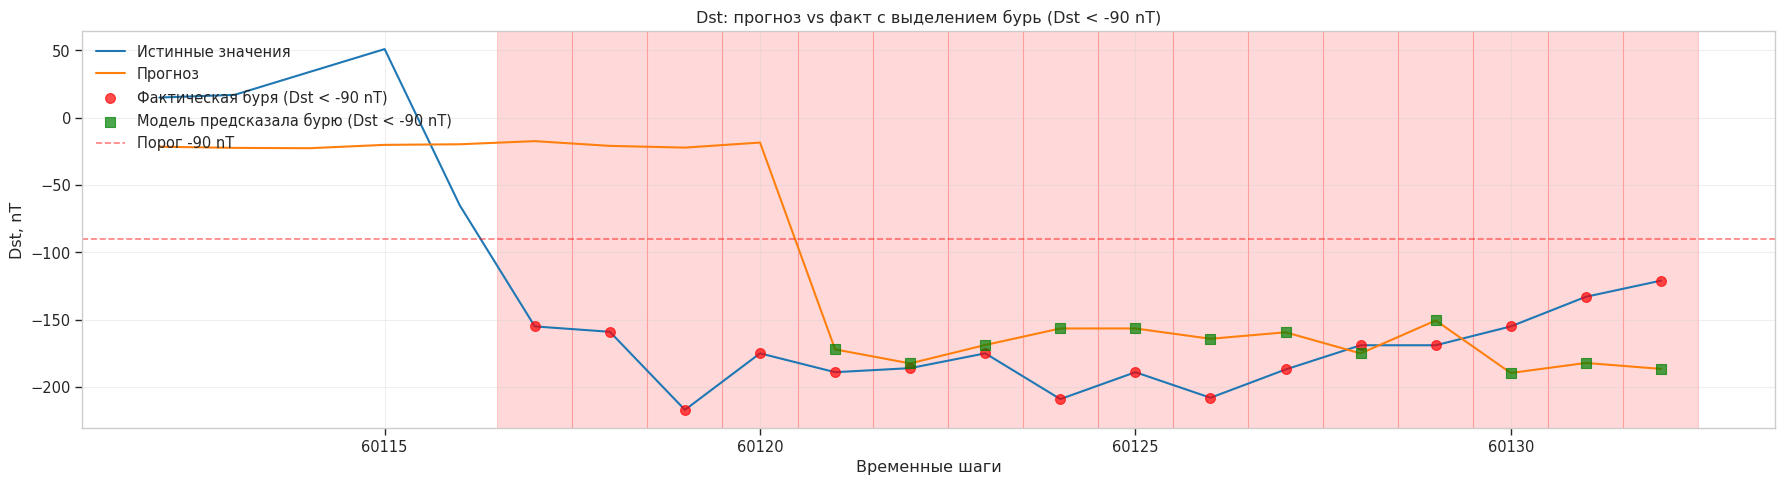

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 16
Всего моментов, когда модель предсказала бурю: 12
Precision: 1.000
Recall: 0.750
F1: 0.857


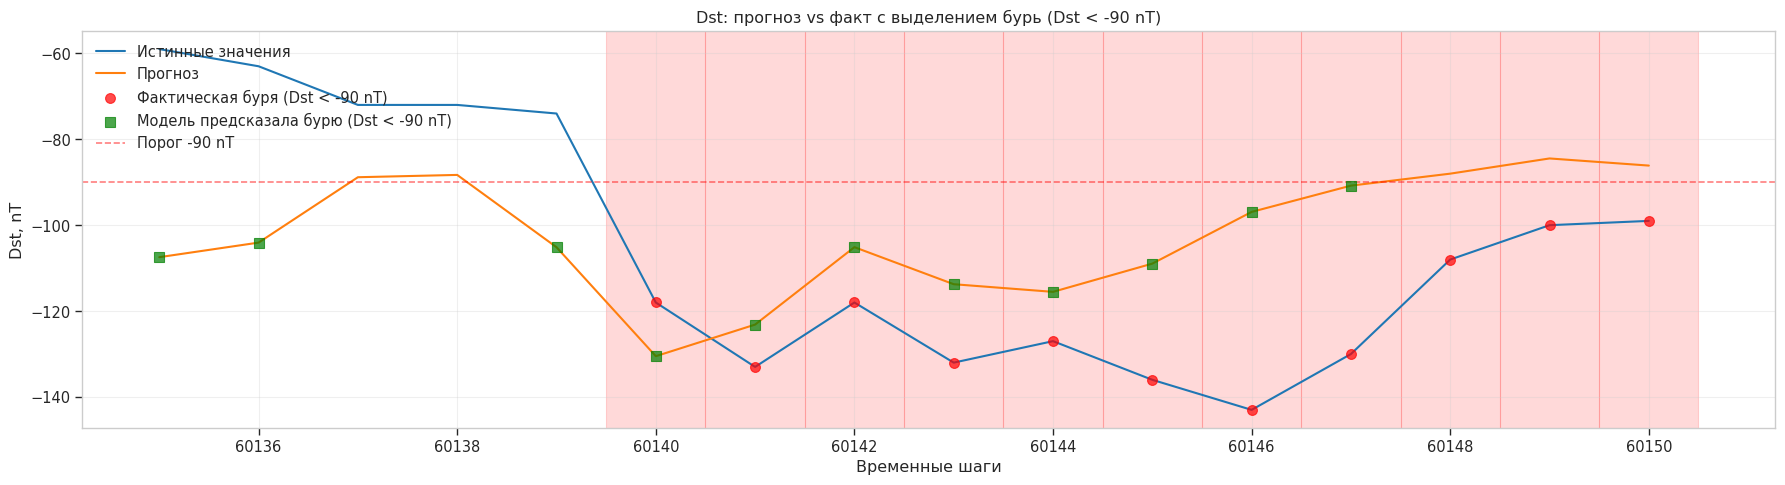

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 11
Всего моментов, когда модель предсказала бурю: 11
Precision: 0.727
Recall: 0.727
F1: 0.727

Средний F1 по всем бурям: 0.702


[np.float64(0.8695652173913044),
 np.float64(0.8648648648648648),
 np.float64(0.7741935483870968),
 np.float64(0.25),
 np.float64(0.4444444444444445),
 np.float64(0.7397260273972603),
 np.float64(0.8947368421052632),
 np.float64(0.625),
 np.float64(0.7142857142857143),
 np.float64(0.9230769230769231),
 np.float64(0.92),
 np.float64(0.8823529411764706),
 np.float64(0.75),
 np.float64(0.6666666666666666),
 np.float64(0.7499999999999999),
 np.float64(0.7272727272727273),
 np.float64(0.4),
 np.float64(0.25),
 np.float64(0.8571428571428571),
 np.float64(0.7272727272727273)]

In [37]:
result = inference_on_loader_pipeline(
    net,
    loader_2019_2025,
    y_scaler,
    device,
    visualize=True,
    until=-300
)
draw_dst_storm_prediction(
    result,
    storm_threshold=-90, 
    padding=5, 
    min_duration=5, 
    min_depth=5,
    above=False  
)

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# Настройка научного стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Цветовая палитра для научных работ
colors = {
    'dst': '#2E86AB',      # Спокойный синий
    'ae': '#D64933',       # Приглушенный красный
    'loss': '#4E9F3D',     # Зеленый
    'val': '#6C757D',      # Серый
    'best': '#F18F01'      # Оранжевый для best моделей
}

def visualize_training_results(history_train, history_val, save_dir='./plots'):
    """
    Визуализация результатов обучения модели прогнозирования геомагнитной активности
    
    Parameters:
    -----------
    history_train : dict
        Словарь с метриками на train
    history_val : dict
        Словарь с метриками на val
    save_dir : str
        Директория для сохранения графиков
    """
    os.makedirs(save_dir, exist_ok=True)
    
    epochs = len(history_train['dst_loss'])
    
    # ==================== 1. Функции потерь ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1.1 Общая loss
    ax = axes[0, 0]
    ax.plot(range(1, epochs+1), history_train['summary_loss'], 
            label='Train', linewidth=2, color=colors['loss'])
    ax.plot(range(1, epochs+1), history_val['loss'], 
            label='Validation', linewidth=2, color=colors['val'], linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Общая функция потерь', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 1.2 DST loss
    ax = axes[0, 1]
    ax.plot(range(1, epochs+1), history_train['dst_loss'], 
            label='Train', linewidth=2, color=colors['dst'])
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('DST Loss', fontsize=12)
    ax.set_title('Потери для DST индекса', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 1.3 AE loss
    ax = axes[1, 0]
    ax.plot(range(1, epochs+1), history_train['ae_loss'], 
            label='Train', linewidth=2, color=colors['ae'])
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('AE Loss', fontsize=12)
    ax.set_title('Потери для AE индекса', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 1.4 Learning rate
    ax = axes[1, 1]
    lr_values = [lr[0] for lr in history_train['lr']]
    ax.plot(range(1, epochs+1), lr_values, 
            linewidth=2, color=colors['best'])
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate', fontsize=12)
    ax.set_title('Динамика learning rate', fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '1_losses_and_lr.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 2. RMSE метрики ====================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 2.1 DST RMSE
    ax = axes[0]
    ax.plot(range(1, epochs+1), history_train['dst']['RMSE'], 
            label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['dst']['RMSE'], 
            label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
    
    # Отмечаем лучшую модель
    best_val_dst_idx = np.argmin(history_val['dst']['RMSE'])
    ax.scatter(best_val_dst_idx+1, history_val['dst']['RMSE'][best_val_dst_idx],
              color=colors['best'], s=150, zorder=5, 
              label=f'Best: {history_val["dst"]["RMSE"][best_val_dst_idx]:.2f}')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('RMSE, nT', fontsize=12)
    ax.set_title('DST RMSE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 2.2 AE RMSE
    ax = axes[1]
    ax.plot(range(1, epochs+1), history_train['ae']['RMSE'], 
            label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['ae']['RMSE'], 
            label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
    
    best_val_ae_idx = np.argmin(history_val['ae']['RMSE'])
    ax.scatter(best_val_ae_idx+1, history_val['ae']['RMSE'][best_val_ae_idx],
              color=colors['best'], s=150, zorder=5,
              label=f'Best: {history_val["ae"]["RMSE"][best_val_ae_idx]:.2f}')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('RMSE, nT', fontsize=12)
    ax.set_title('AE RMSE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '2_rmse_metrics.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 3. MAPE и MAE ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 3.1 DST MAPE
    ax = axes[0, 0]
    ax.plot(range(1, epochs+1), history_train['dst']['MAPE'], 
            label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['dst']['MAPE'], 
            label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MAPE, %', fontsize=12)
    ax.set_title('DST MAPE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 3.2 AE MAPE
    ax = axes[0, 1]
    ax.plot(range(1, epochs+1), history_train['ae']['MAPE'], 
            label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['ae']['MAPE'], 
            label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MAPE, %', fontsize=12)
    ax.set_title('AE MAPE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 3.3 DST MAE
    ax = axes[1, 0]
    ax.plot(range(1, epochs+1), history_train['dst']['MAE'], 
            label='Train', linewidth=2, color=colors['dst'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['dst']['MAE'], 
            label='Validation', linewidth=2, color=colors['dst'], linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MAE, nT', fontsize=12)
    ax.set_title('DST MAE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # 3.4 AE MAE
    ax = axes[1, 1]
    ax.plot(range(1, epochs+1), history_train['ae']['MAE'], 
            label='Train', linewidth=2, color=colors['ae'], alpha=0.7)
    ax.plot(range(1, epochs+1), history_val['ae']['MAE'], 
            label='Validation', linewidth=2, color=colors['ae'], linestyle='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MAE, nT', fontsize=12)
    ax.set_title('AE MAE', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '3_mape_mae_metrics.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 4. Сводная таблица метрик ====================
    best_epoch_loss = np.argmin(history_val['loss']) + 1
    best_epoch_dst = np.argmin(history_val['dst']['RMSE']) + 1
    best_epoch_ae = np.argmin(history_val['ae']['RMSE']) + 1
    
    # Создаем DataFrame с итоговыми метриками
    results = {
        'Метрика': ['Loss', 'DST RMSE (nT)', 'AE RMSE (nT)', 
                   'DST MAPE (%)', 'AE MAPE (%)', 'DST MAE (nT)', 'AE MAE (nT)'],
        'Лучшее значение': [
            f'{history_val["loss"][best_epoch_loss-1]:.4f}',
            f'{history_val["dst"]["RMSE"][best_epoch_dst-1]:.2f}',
            f'{history_val["ae"]["RMSE"][best_epoch_ae-1]:.2f}',
            f'{history_val["dst"]["MAPE"][best_epoch_dst-1]:.2f}',
            f'{history_val["ae"]["MAPE"][best_epoch_ae-1]:.2f}',
            f'{history_val["dst"]["MAE"][best_epoch_dst-1]:.2f}',
            f'{history_val["ae"]["MAE"][best_epoch_ae-1]:.2f}'
        ],
        'Эпоха': [
            best_epoch_loss,
            best_epoch_dst,
            best_epoch_ae,
            best_epoch_dst,
            best_epoch_ae,
            best_epoch_dst,
            best_epoch_ae
        ]
    }
    
    results_df = pd.DataFrame(results)
    
    # Визуализируем таблицу
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('tight')
    ax.axis('off')
    
    # Создаем таблицу
    table = ax.table(cellText=results_df.values,
                     colLabels=results_df.columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#4472C4']*3,
                     colWidths=[0.35, 0.35, 0.15])
    
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    
    # Стилизация таблицы
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_text_props(color='white', fontweight='bold')
        if i > 0:
            cell.set_text_props(color='black')
        cell.set_edgecolor('black')
        cell.set_linewidth(0.5)
    
    plt.title('Итоговые метрики модели', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '4_summary_table.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 5. Сравнение train/val метрик ====================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = [
        ('DST RMSE', 'dst', 'RMSE'),
        ('AE RMSE', 'ae', 'RMSE'),
        ('DST MAPE', 'dst', 'MAPE'),
        ('AE MAPE', 'ae', 'MAPE')
    ]
    
    for idx, (title, target, metric) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        
        train_metric = history_train[target][metric]
        val_metric = history_val[target][metric]
        
        ax.plot(range(1, epochs+1), train_metric, 
                label='Train', linewidth=2, alpha=0.7)
        ax.plot(range(1, epochs+1), val_metric, 
                label='Validation', linewidth=2, linestyle='--')
        
        # Отмечаем лучшую валидационную метрику
        best_idx = np.argmin(val_metric)
        ax.scatter(best_idx+1, val_metric[best_idx],
                  color=colors['best'], s=150, zorder=5,
                  label=f'Best: {val_metric[best_idx]:.2f}')
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(title, fontsize=12)
        ax.set_title(f'{title} (Train vs Validation)', fontsize=14)
        ax.legend(frameon=True, fancybox=True, shadow=True)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '5_train_val_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 6. Соотношение сигма ====================
    # Анализ влияния весов на потери
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Нормализованные потери для сравнения
    dst_loss_norm = np.array(history_train['dst_loss']) / np.max(history_train['dst_loss'])
    ae_loss_norm = np.array(history_train['ae_loss']) / np.max(history_train['ae_loss'])
    
    ax.plot(range(1, epochs+1), dst_loss_norm, 
            label='DST Loss (норм.)', linewidth=2, color=colors['dst'])
    ax.plot(range(1, epochs+1), ae_loss_norm, 
            label='AE Loss (норм.)', linewidth=2, color=colors['ae'])
    
    # Добавляем информацию о весах
    ax.text(0.02, 0.95, f'DST weight = {dst_loss_sigma:.1f}\nAE weight = {ae_loss_sigma:.1f}',
            transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Нормализованные потери', fontsize=12)
    ax.set_title('Динамика нормализованных потерь', fontsize=14)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '6_normalized_losses.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # ==================== 7. Boxplot финальных метрик ====================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Собираем последние 10% эпох для анализа стабильности
    last_n = max(10, int(epochs * 0.1))
    
    # DST RMSE
    ax = axes[0]
    data_to_plot = [
        history_train['dst']['RMSE'][-last_n:],
        history_val['dst']['RMSE'][-last_n:]
    ]
    bp = ax.boxplot(data_to_plot, labels=['Train', 'Validation'], 
                    patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor(colors['dst'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(colors['dst'])
    bp['boxes'][1].set_alpha(0.3)
    
    ax.set_ylabel('DST RMSE, nT', fontsize=12)
    ax.set_title(f'Распределение DST RMSE (последние {last_n} эпох)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # AE RMSE
    ax = axes[1]
    data_to_plot = [
        history_train['ae']['RMSE'][-last_n:],
        history_val['ae']['RMSE'][-last_n:]
    ]
    bp = ax.boxplot(data_to_plot, labels=['Train', 'Validation'], 
                    patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor(colors['ae'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(colors['ae'])
    bp['boxes'][1].set_alpha(0.3)
    
    ax.set_ylabel('AE RMSE, nT', fontsize=12)
    ax.set_title(f'Распределение AE RMSE (последние {last_n} эпох)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, '7_boxplot_metrics.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*60}")
    print("Визуализация завершена! Все графики сохранены в:", save_dir)
    print(f"{'='*60}")
    
    # Возвращаем сводку лучших метрик для презентации
    summary = {
        'best_loss_epoch': best_epoch_loss,
        'best_loss_value': history_val['loss'][best_epoch_loss-1],
        'best_dst_epoch': best_epoch_dst,
        'best_dst_rmse': history_val['dst']['RMSE'][best_epoch_dst-1],
        'best_ae_epoch': best_epoch_ae,
        'best_ae_rmse': history_val['ae']['RMSE'][best_epoch_ae-1],
    }
    
    return summary

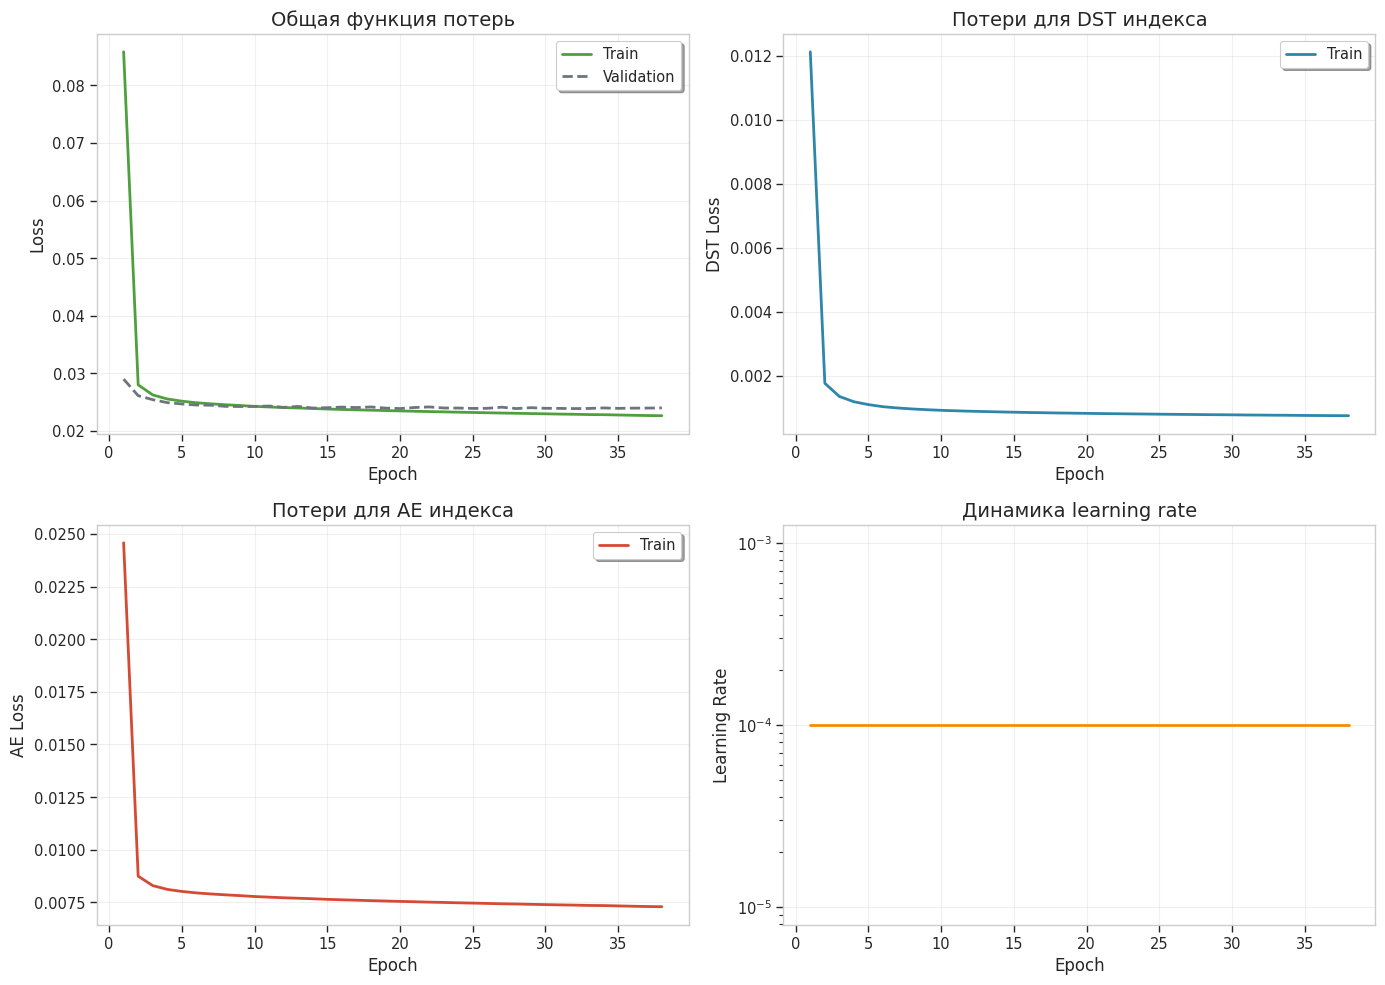

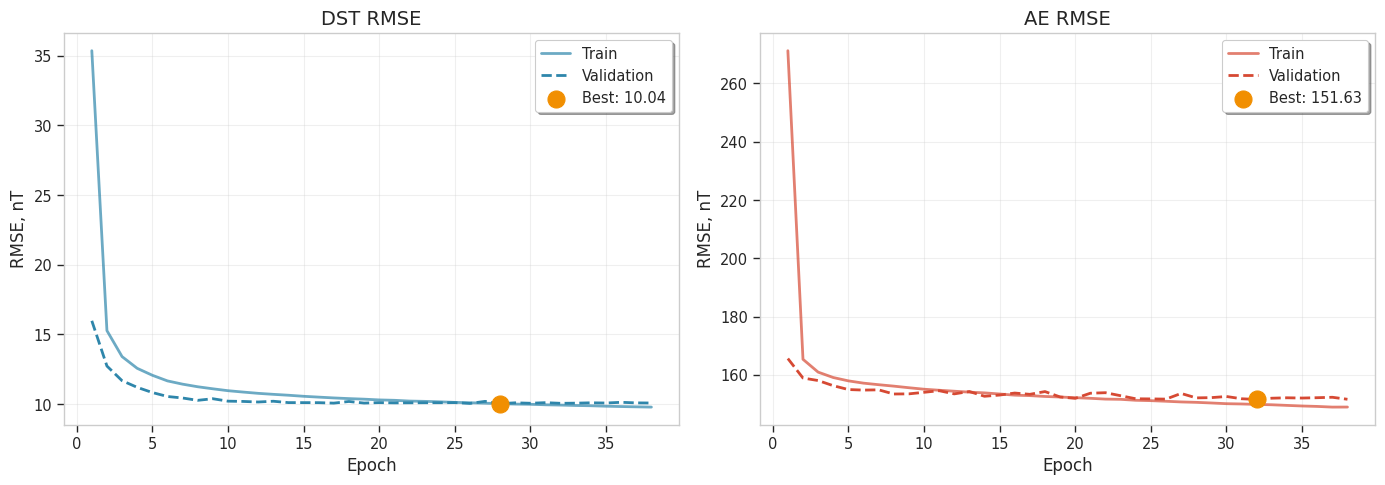

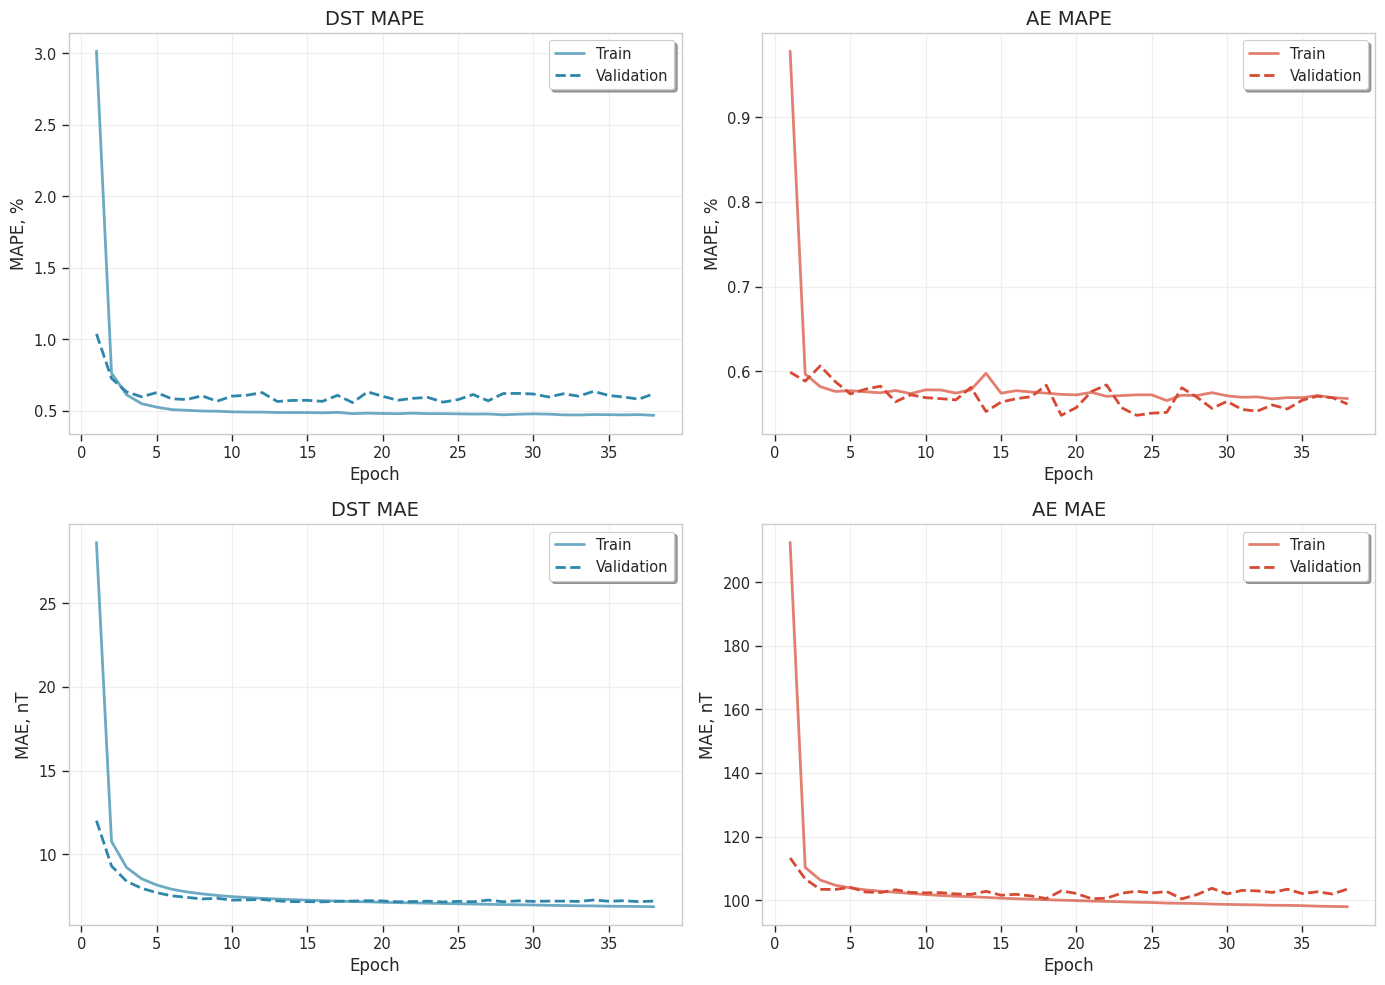

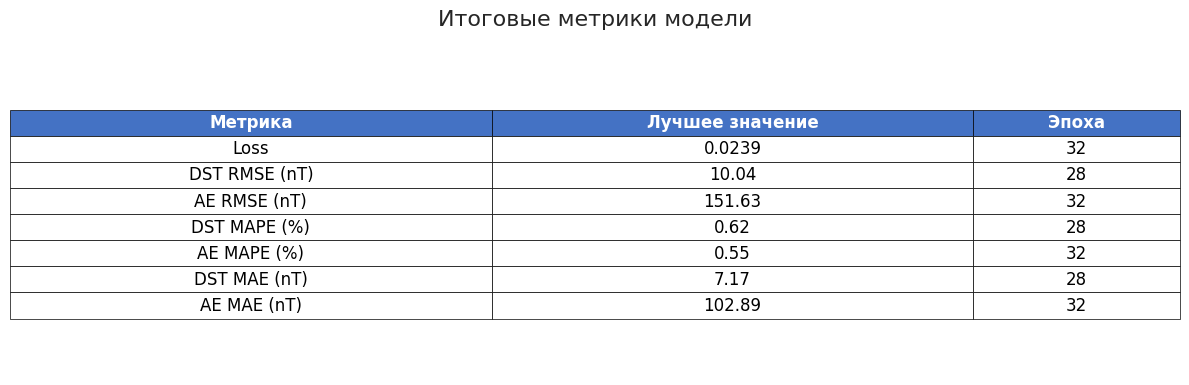

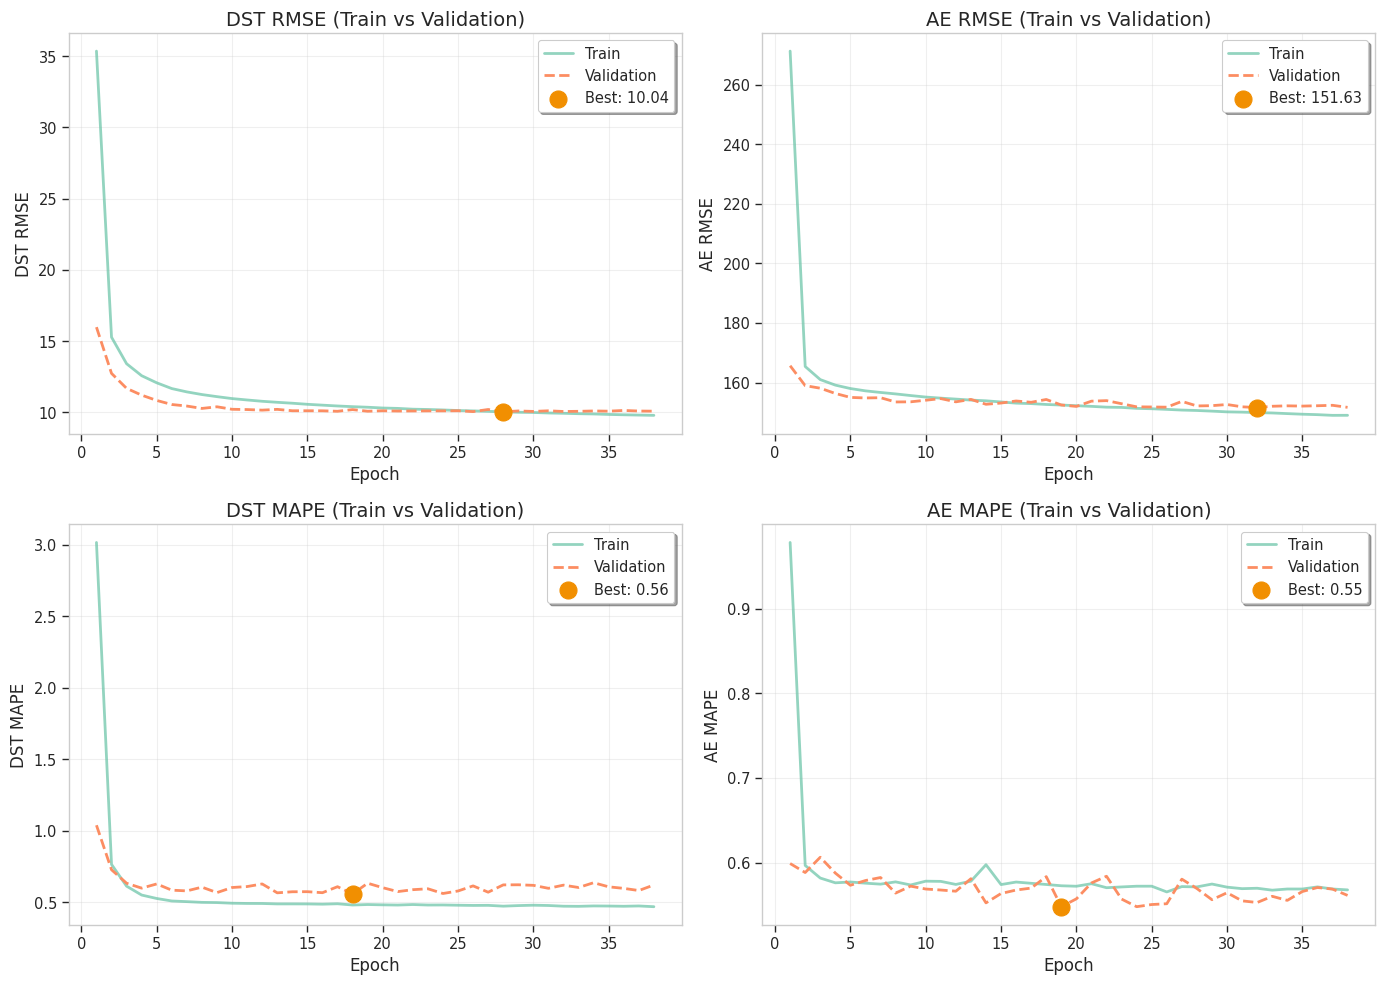

NameError: name 'dst_loss_sigma' is not defined

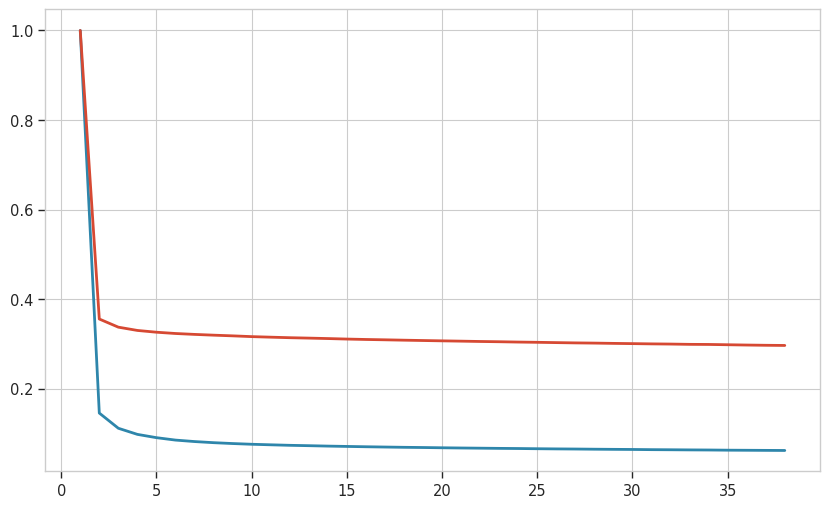

In [39]:
summary = visualize_training_results(th, vh, save_dir='./training_plots')

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score

In [41]:
def dst_to_class(dst):
    if isinstance(dst, (int, float)):
        if dst > -50:
            return 0
        elif dst > -100:
            return 1
        elif dst > -200:
            return 2
        else:
            return 3
    
    dst = np.array(dst)
    classes = np.zeros_like(dst, dtype=int)
    classes[dst > -50] = 0
    classes[(dst <= -50) & (dst > -100)] = 1
    classes[(dst <= -100) & (dst > -200)] = 2
    classes[dst <= -200] = 3
    
    return classes

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
dst_labels = dst_to_class(result["dst_labels"])
dst_preds = dst_to_class(result["dst_preds"])

cr = classification_report(dst_labels, dst_preds)
# cm = confusion_matrix(dst_labels, dst_preds)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     59186
           1       0.48      0.50      0.49      1559
           2       0.41      0.48      0.44       224
           3       0.70      0.35      0.46        46

    accuracy                           0.97     61015
   macro avg       0.64      0.58      0.60     61015
weighted avg       0.97      0.97      0.97     61015



In [255]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import torch
# from typing import List, Tuple, Optional
# import pandas as pd
# from matplotlib.patches import Rectangle

# def extract_attention_weights(
#     model,
#     loader,
#     device='cuda',
#     num_samples=10,
#     return_predictions=False
# ):
#     """
#     Извлечение весов внимания для нескольких батчей
#     """
#     model.eval()
    
#     all_dst_attn = []
#     all_ae_attn = []
#     all_inputs = []
#     all_predictions = []
#     all_targets = []
    
#     with torch.no_grad():
#         for batch_idx, (x, y) in enumerate(loader):
#             if batch_idx >= num_samples:
#                 break
                
#             x = x.to(device)
#             y = y.to(device)
            
#             # Получаем предсказания и веса внимания
#             dst_pred, ae_pred, (dst_attn_w, ae_attn_w) = model(x)
            
#             # Сохраняем
#             all_dst_attn.append(dst_attn_w.cpu().numpy())
#             all_ae_attn.append(ae_attn_w.cpu().numpy())
#             all_inputs.append(x.cpu().numpy())
#             all_predictions.append({
#                 'dst': dst_pred.cpu().numpy(),
#                 'ae': ae_pred.cpu().numpy()
#             })
#             all_targets.append(y.cpu().numpy())
    
#     return {
#         'dst_attention': all_dst_attn,
#         'ae_attention': all_ae_attn,
#         'inputs': all_inputs,
#         'predictions': all_predictions,
#         'targets': all_targets
#     }

# def visualize_attention_weights(
#     attention_data,
#     feature_names=None,
#     sample_idx=0,
#     batch_idx=0,
#     figsize=(15, 10)
# ):
#     """
#     Визуализация весов внимания для одного батча
#     """
#     # Извлекаем данные
#     dst_attn = attention_data['dst_attention'][batch_idx]  # [batch, heads, seq_len]
#     ae_attn = attention_data['ae_attention'][batch_idx]    # [batch, heads, seq_len]
    
#     # Берем один образец
#     dst_weights = dst_attn[sample_idx]  # [heads, seq_len]
#     ae_weights = ae_attn[sample_idx]    # [heads, seq_len]
    
#     seq_len = dst_weights.shape[1]
    
#     fig, axes = plt.subplots(2, 2, figsize=figsize)
    
#     # 1. DST внимание - все головы
#     ax1 = axes[0, 0]
#     for head_idx in range(dst_weights.shape[0]):
#         ax1.plot(dst_weights[head_idx], label=f'Head {head_idx+1}', alpha=0.7)
#     ax1.set_title(f'DST Attention Weights (Sample {sample_idx})')
#     ax1.set_xlabel('Time steps')
#     ax1.set_ylabel('Attention weight')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)
    
#     # 2. AE внимание - все головы
#     ax2 = axes[0, 1]
#     for head_idx in range(ae_weights.shape[0]):
#         ax2.plot(ae_weights[head_idx], label=f'Head {head_idx+1}', alpha=0.7)
#     ax2.set_title(f'AE Attention Weights (Sample {sample_idx})')
#     ax2.set_xlabel('Time steps')
#     ax2.set_ylabel('Attention weight')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)
    
#     # 3. Тепловая карта DST внимания
#     ax3 = axes[1, 0]
#     im = ax3.imshow(dst_weights, aspect='auto', cmap='YlOrRd')
#     ax3.set_title('DST Attention Heatmap')
#     ax3.set_xlabel('Time steps')
#     ax3.set_ylabel('Attention heads')
#     plt.colorbar(im, ax=ax3)
    
#     # 4. Тепловая карта AE внимания
#     ax4 = axes[1, 1]
#     im = ax4.imshow(ae_weights, aspect='auto', cmap='YlOrRd')
#     ax4.set_title('AE Attention Heatmap')
#     ax4.set_xlabel('Time steps')
#     ax4.set_ylabel('Attention heads')
#     plt.colorbar(im, ax=ax4)
    
#     plt.tight_layout()
#     plt.show()
    
#     return fig

# def analyze_attention_by_feature(
#     model,
#     loader,
#     feature_names,
#     device='cuda',
#     num_samples=50,
#     time_window=24*6  # 6 часов (если данные почасовые)
# ):
#     """
#     Анализ того, на какие признаки модель обращает внимание
#     """
#     model.eval()
    
#     # Для накопления статистики
#     dst_attention_by_feature = {name: [] for name in feature_names}
#     ae_attention_by_feature = {name: [] for name in feature_names}
    
#     with torch.no_grad():
#         for batch_idx, (x, y) in enumerate(loader):
#             if batch_idx >= num_samples:
#                 break
                
#             x = x.to(device)
            
#             # Получаем внимание
#             _, _, (dst_attn_w, ae_attn_w) = model(x)
            
#             # dst_attn_w: [batch, heads, seq_len]
#             # Усредняем по головам и батчу
#             dst_mean = dst_attn_w.mean(dim=0).mean(dim=0).cpu().numpy()  # [seq_len]
#             ae_mean = ae_attn_w.mean(dim=0).mean(dim=0).cpu().numpy()    # [seq_len]
            
#             # Для каждого признака смотрим его вклад в момент времени
#             # Здесь мы смотрим на последний временной шаг (самый важный для прогноза)
#             # И распределяем внимание по признакам
#             last_step_dst = dst_mean[-1]  # Внимание на последнем шаге
#             last_step_ae = ae_mean[-1]
            
#             # Получаем значения признаков на последнем шаге
#             x_last = x[:, -1, :].cpu().numpy()  # [batch, features]
            
#             # Для каждого признака вычисляем его "вклад" в внимание
#             for feat_idx, feat_name in enumerate(feature_names):
#                 # Нормализуем вклад признака
#                 feature_contribution = np.abs(x_last[:, feat_idx])
#                 feature_contribution = feature_contribution / (feature_contribution.sum() + 1e-8)
                
#                 # Взвешиваем внимание на этот признак
#                 dst_attention_by_feature[feat_name].append(
#                     last_step_dst * feature_contribution.mean()
#                 )
#                 ae_attention_by_feature[feat_name].append(
#                     last_step_ae * feature_contribution.mean()
#                 )
    
#     # Усредняем
#     dst_avg = {name: np.mean(values) for name, values in dst_attention_by_feature.items()}
#     ae_avg = {name: np.mean(values) for name, values in ae_attention_by_feature.items()}
    
#     return pd.DataFrame({
#         'feature': list(dst_avg.keys()),
#         'dst_attention': list(dst_avg.values()),
#         'ae_attention': list(ae_avg.values())
#     })

# def visualize_attention_temporal_patterns(
#     model,
#     loader,
#     feature_names=None,
#     device='cuda',
#     num_samples=100,
#     save_path=None
# ):
#     """
#     Визуализация временных паттернов внимания
#     """
#     model.eval()
    
#     all_dst_attn = []
#     all_ae_attn = []
#     all_predictions = []
    
#     with torch.no_grad():
#         for batch_idx, (x, y) in enumerate(loader):
#             if batch_idx >= num_samples:
#                 break
                
#             x = x.to(device)
#             dst_pred, ae_pred, (dst_attn_w, ae_attn_w) = model(x)
            
#             # Усредняем по головам и батчу
#             dst_mean = dst_attn_w.mean(dim=0).mean(dim=0).cpu().numpy()  # [seq_len]
#             ae_mean = ae_attn_w.mean(dim=0).mean(dim=0).cpu().numpy()    # [seq_len]
            
#             all_dst_attn.append(dst_mean)
#             all_ae_attn.append(ae_mean)
#             all_predictions.append({
#                 'dst': dst_pred.cpu().numpy(),
#                 'ae': ae_pred.cpu().numpy()
#             })
    
#     # Усредняем по всем батчам
#     dst_avg = np.mean(all_dst_attn, axis=0)
#     ae_avg = np.mean(all_ae_attn, axis=0)
#     dst_std = np.std(all_dst_attn, axis=0)
#     ae_std = np.std(all_ae_attn, axis=0)
    
#     seq_len = len(dst_avg)
    
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     # 1. DST внимание с доверительным интервалом
#     ax1 = axes[0, 0]
#     steps = np.arange(seq_len)
#     ax1.plot(steps, dst_avg, 'r-', linewidth=2, label='DST Attention')
#     ax1.fill_between(steps, dst_avg - dst_std, dst_avg + dst_std, alpha=0.3, color='red')
#     ax1.set_title('DST Attention Patterns (averaged over samples)')
#     ax1.set_xlabel('Time steps before prediction')
#     ax1.set_ylabel('Attention weight')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend()
    
#     # 2. AE внимание с доверительным интервалом
#     ax2 = axes[0, 1]
#     ax2.plot(steps, ae_avg, 'b-', linewidth=2, label='AE Attention')
#     ax2.fill_between(steps, ae_avg - ae_std, ae_avg + ae_std, alpha=0.3, color='blue')
#     ax2.set_title('AE Attention Patterns (averaged over samples)')
#     ax2.set_xlabel('Time steps before prediction')
#     ax2.set_ylabel('Attention weight')
#     ax2.grid(True, alpha=0.3)
#     ax2.legend()
    
#     # 3. Сравнение DST и AE внимания
#     ax3 = axes[1, 0]
#     ax3.plot(steps, dst_avg, 'r-', label='DST', linewidth=2)
#     ax3.plot(steps, ae_avg, 'b-', label='AE', linewidth=2)
#     ax3.set_title('DST vs AE Attention Patterns')
#     ax3.set_xlabel('Time steps before prediction')
#     ax3.set_ylabel('Attention weight')
#     ax3.legend()
#     ax3.grid(True, alpha=0.3)
    
#     # 4. Кумулятивное внимание
#     ax4 = axes[1, 1]
#     dst_cumsum = np.cumsum(dst_avg) / np.sum(dst_avg)
#     ae_cumsum = np.cumsum(ae_avg) / np.sum(ae_avg)
#     ax4.plot(steps, dst_cumsum, 'r-', label='DST', linewidth=2)
#     ax4.plot(steps, ae_cumsum, 'b-', label='AE', linewidth=2)
#     ax4.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50%')
#     ax4.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90%')
#     ax4.set_title('Cumulative Attention Distribution')
#     ax4.set_xlabel('Time steps before prediction')
#     ax4.set_ylabel('Cumulative weight')
#     ax4.legend()
#     ax4.grid(True, alpha=0.3)
    
#     plt.suptitle('Temporal Attention Patterns Analysis', fontsize=14)
#     plt.tight_layout()
    
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # Выводим статистику
#     print("="*60)
#     print("ATTENTION PATTERN ANALYSIS")
#     print("="*60)
    
#     # Находим наиболее важные временные шаги
#     dst_top5 = np.argsort(dst_avg)[-5:][::-1]
#     ae_top5 = np.argsort(ae_avg)[-5:][::-1]
    
#     print(f"\nТоп-5 наиболее важных моментов для DST:")
#     for i, idx in enumerate(dst_top5, 1):
#         print(f"  {i}. Шаг {idx} (за {seq_len - idx} часов до прогноза): вес = {dst_avg[idx]:.4f}")
    
#     print(f"\nТоп-5 наиболее важных моментов для AE:")
#     for i, idx in enumerate(ae_top5, 1):
#         print(f"  {i}. Шаг {idx} (за {seq_len - idx} часов до прогноза): вес = {ae_avg[idx]:.4f}")
    
#     # Вычисляем эффективную длину контекста
#     dst_eff_len = np.argmax(dst_cumsum >= 0.9) + 1
#     ae_eff_len = np.argmax(ae_cumsum >= 0.9) + 1
    
#     print(f"\nЭффективная длина контекста (90% внимания):")
#     print(f"  DST: {dst_eff_len} шагов")
#     print(f"  AE:  {ae_eff_len} шагов")
    
#     return {
#         'dst_attention': dst_avg,
#         'ae_attention': ae_avg,
#         'dst_cumsum': dst_cumsum,
#         'ae_cumsum': ae_cumsum,
#         'effective_length': {'dst': dst_eff_len, 'ae': ae_eff_len}
#     }

# def analyze_attention_by_storm_strength(
#     model,
#     loader,
#     y_scaler,
#     device='cuda',
#     thresholds=[-50, -100, -200],
#     num_samples=100
# ):
#     """
#     Анализ внимания в зависимости от силы бури
#     """
#     model.eval()
    
#     storm_levels = {
#         0: {'name': 'No storm', 'dst': [], 'attn': []},
#         1: {'name': 'Weak storm', 'dst': [], 'attn': []},
#         2: {'name': 'Moderate storm', 'dst': [], 'attn': []},
#         3: {'name': 'Strong storm', 'dst': [], 'attn': []}
#     }
    
#     with torch.no_grad():
#         for batch_idx, (x, y) in enumerate(loader):
#             if batch_idx >= num_samples:
#                 break
                
#             x = x.to(device)
#             y = y.to(device)
            
#             # Получаем предсказания и внимание
#             dst_pred, ae_pred, (dst_attn_w, ae_attn_w) = model(x)
            
#             # Преобразуем DST в классы
#             dst_true = y[:, 0, 0].cpu().numpy()
#             dst_true_orig = y_scaler.inverse_transform(
#                 np.hstack([dst_true.reshape(-1, 1), np.zeros((len(dst_true), 1))])
#             )[:, 0]
            
#             classes = np.zeros_like(dst_true_orig, dtype=int)
#             classes[dst_true_orig > -50] = 0
#             classes[(dst_true_orig <= -50) & (dst_true_orig > -100)] = 1
#             classes[(dst_true_orig <= -100) & (dst_true_orig > -200)] = 2
#             classes[dst_true_orig <= -200] = 3
            
#             # Усредняем внимание по головам
#             dst_attn_mean = dst_attn_w.mean(dim=1).cpu().numpy()  # [batch, seq_len]
            
#             # Распределяем по классам
#             for i, cls in enumerate(classes):
#                 storm_levels[cls]['dst'].append(dst_true_orig[i])
#                 storm_levels[cls]['attn'].append(dst_attn_mean[i])
    
#     # Визуализация
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     colors = ['green', 'yellow', 'orange', 'red']
    
#     for idx, (level, data) in enumerate(storm_levels.items()):
#         ax = axes[idx // 2, idx % 2]
        
#         if len(data['attn']) > 0:
#             # Усредняем внимание для этого уровня
#             mean_attn = np.mean(data['attn'], axis=0)
#             std_attn = np.std(data['attn'], axis=0)
#             steps = np.arange(len(mean_attn))
            
#             ax.plot(steps, mean_attn, color=colors[idx], linewidth=2, 
#                    label=f'{data["name"]} (n={len(data["attn"])})')
#             ax.fill_between(steps, mean_attn - std_attn, mean_attn + std_attn, 
#                            alpha=0.3, color=colors[idx])
            
#             # Добавляем информацию о среднем DST
#             avg_dst = np.mean(data['dst'])
#             ax.text(0.02, 0.95, f'Avg DST: {avg_dst:.1f} nT', 
#                    transform=ax.transAxes, fontsize=10,
#                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
#         else:
#             ax.text(0.5, 0.5, f'No samples for {data["name"]}', 
#                    ha='center', va='center', transform=ax.transAxes)
        
#         ax.set_title(f'Attention Pattern: {data["name"]}')
#         ax.set_xlabel('Time steps before prediction')
#         ax.set_ylabel('Attention weight')
#         ax.legend()
#         ax.grid(True, alpha=0.3)
    
#     plt.suptitle('Attention Patterns by Storm Strength', fontsize=14)
#     plt.tight_layout()
#     plt.show()
    
#     return storm_levels

# def interpret_attention_for_burst_detection(
#     model,
#     loader,
#     y_scaler,
#     feature_names,
#     device='cuda',
#     thresholds=[-50, -100, -200],
#     save_dir='./attention_analysis'
# ):
#     """
#     Комплексный анализ внимания для обнаружения бурь
#     """
#     import os
#     os.makedirs(save_dir, exist_ok=True)
    
#     print("="*60)
#     print("INTERPRETING ATTENTION FOR STORM DETECTION")
#     print("="*60)
    
#     # 1. Временные паттерны внимания
#     print("\n1. Analyzing temporal attention patterns...")
#     temporal_results = visualize_attention_temporal_patterns(
#         model, loader, feature_names, device,
#         num_samples=50,
#         save_path=f'{save_dir}/temporal_patterns.png'
#     )
    
#     # 2. Внимание по классам бурь
#     print("\n2. Analyzing attention by storm strength...")
#     storm_attn = analyze_attention_by_storm_strength(
#         model, loader, y_scaler, device, thresholds, num_samples=50
#     )
    
#     # 3. Извлекаем внимание для детального анализа
#     print("\n3. Extracting attention weights...")
#     attention_data = extract_attention_weights(
#         model, loader, device, num_samples=5, return_predictions=True
#     )
    
#     # 4. Визуализируем несколько примеров
#     print("\n4. Visualizing attention for individual samples...")
#     for i in range(min(3, len(attention_data['dst_attention']))):
#         visualize_attention_weights(
#             attention_data,
#             feature_names,
#             sample_idx=0,
#             batch_idx=i,
#             figsize=(12, 8)
#         )
#         plt.savefig(f'{save_dir}/attention_sample_{i}.png', dpi=300, bbox_inches='tight')
#         plt.close()
    
#     # 5. Анализ важности признаков через внимание
#     print("\n5. Feature importance via attention...")
#     feature_attn = analyze_attention_by_feature(
#         model, loader, feature_names, device, num_samples=50
#     )
    
#     # Выводим топ-признаков по вниманию
#     print("\nТоп-5 признаков по вниманию DST:")
#     print(feature_attn.nlargest(5, 'dst_attention')[['feature', 'dst_attention']])
    
#     print("\nТоп-5 признаков по вниманию AE:")
#     print(feature_attn.nlargest(5, 'ae_attention')[['feature', 'ae_attention']])
    
#     # Сохраняем результаты
#     feature_attn.to_csv(f'{save_dir}/feature_attention.csv', index=False)
    
#     # 6. Выводы
#     print("\n" + "="*60)
#     print("KEY INSIGHTS FROM ATTENTION ANALYSIS")
#     print("="*60)
    
#     # Определяем, насколько далеко модель смотрит в прошлое
#     eff_len = temporal_results['effective_length']
#     print(f"\n1. Модель использует контекст длиной:")
#     print(f"   - Для DST: {eff_len['dst']} шагов ({(eff_len['dst']/24):.1f} суток)")
#     print(f"   - Для AE:  {eff_len['ae']} шагов ({(eff_len['ae']/24):.1f} суток)")
    
#     # Находим самый важный момент времени
#     dst_peak = np.argmax(temporal_results['dst_attention'])
#     ae_peak = np.argmax(temporal_results['ae_attention'])
#     total_len = len(temporal_results['dst_attention'])
    
#     print(f"\n2. Наиболее важные моменты времени:")
#     print(f"   - DST: за {total_len - dst_peak} часов до прогноза")
#     print(f"   - AE:  за {total_len - ae_peak} часов до прогноза")
    
#     # Проверяем, различается ли внимание для разных классов бурь
#     print(f"\n3. Внимание для разных классов бурь:")
#     for level, data in storm_attn.items():
#         if len(data['attn']) > 0:
#             mean_attn = np.mean(data['attn'], axis=0)
#             peak_step = np.argmax(mean_attn)
#             print(f"   - {storm_attn[level]['name']}: пик внимания на шаге {peak_step} (за {total_len - peak_step} часов)")
    
#     return {
#         'temporal_patterns': temporal_results,
#         'storm_attention': storm_attn,
#         'feature_attention': feature_attn,
#         'attention_data': attention_data
#     }

# # ==================== ПРИМЕНЕНИЕ ====================

# # Запускаем комплексный анализ внимания
# attention_analysis = interpret_attention_for_burst_detection(
#     model=net,
#     loader=loader_2019_2025,
#     y_scaler=y_scaler,
#     feature_names=[
#         'Bz_GSM', 'By_GSM', 'Bx_GSE', 'Kp', 'f10.7', 'AL', 'AU', 'T_proton',
#         'Np_density', 'V_plasma', 'V_Long_GSE', 'V_Lat_GSE', 'AE', 'hour_sin',
#         'hour_cos', 'day_sin', 'day_cos', 'week_sin', 'week_cos'
#     ],
#     device=device,
#     thresholds=[-50, -100, -200],
#     save_dir='./attention_analysis'
# )

# # Анализ конкретного примера с бур
# def analyze_storm_example(
#     model,
#     loader,
#     y_scaler,
#     feature_names,
#     device='cuda',
#     storm_threshold=-200,
#     save_dir='./storm_attention_analysis'
# ):
#     """
#     Детальный анализ внимания для примеров с сильными бурями
#     """
#     import os
#     os.makedirs(save_dir, exist_ok=True)
    
#     model.eval()
    
#     storm_examples = []
    
#     with torch.no_grad():
#         for batch_idx, (x, y) in enumerate(loader):
#             x = x.to(device)
#             y = y.to(device)
            
#             # Получаем предсказания и внимание
#             dst_pred, ae_pred, (dst_attn_w, ae_attn_w) = model(x)
            
#             # Преобразуем DST в оригинальную шкалу
#             dst_true = y[:, 0, 0].cpu().numpy()
#             dst_true_orig = y_scaler.inverse_transform(
#                 np.hstack([dst_true.reshape(-1, 1), np.zeros((len(dst_true), 1))])
#             )[:, 0]
            
#             # Ищем сильные бури
#             storm_indices = np.where(dst_true_orig <= storm_threshold)[0]
            
#             for idx in storm_indices:
#                 storm_examples.append({
#                     'batch_idx': batch_idx,
#                     'sample_idx': idx,
#                     'dst': dst_true_orig[idx],
#                     'x': x[idx].cpu().numpy(),
#                     'dst_attention': dst_attn_w[idx].cpu().numpy(),  # [heads, seq_len]
#                     'ae_attention': ae_attn_w[idx].cpu().numpy(),    # [heads, seq_len]
#                     'dst_pred': dst_pred[idx].cpu().numpy(),
#                     'ae_pred': ae_pred[idx].cpu().numpy()
#                 })
                
#                 if len(storm_examples) >= 10:  # Берем первые 10 бурь
#                     break
            
#             if len(storm_examples) >= 10:
#                 break
    
#     # Визуализируем каждый пример с бурей
#     for i, example in enumerate(storm_examples):
#         fig, axes = plt.subplots(3, 1, figsize=(15, 12))
        
#         seq_len = example['x'].shape[0]
        
#         # 1. Внимание DST
#         ax1 = axes[0]
#         for head_idx in range(example['dst_attention'].shape[0]):
#             ax1.plot(example['dst_attention'][head_idx], 
#                     label=f'Head {head_idx+1}', alpha=0.7)
#         ax1.set_title(f'DST Attention - Storm {i+1} (Dst = {example["dst"]:.1f} nT)')
#         ax1.set_xlabel('Time steps before prediction')
#         ax1.set_ylabel('Attention weight')
#         ax1.legend()
#         ax1.grid(True, alpha=0.3)
        
#         # 2. Внимание AE
#         ax2 = axes[1]
#         for head_idx in range(example['ae_attention'].shape[0]):
#             ax2.plot(example['ae_attention'][head_idx], 
#                     label=f'Head {head_idx+1}', alpha=0.7)
#         ax2.set_title('AE Attention')
#         ax2.set_xlabel('Time steps before prediction')
#         ax2.set_ylabel('Attention weight')
#         ax2.legend()
#         ax2.grid(True, alpha=0.3)
        
#         # 3. Тепловая карта всех признаков
#         ax3 = axes[2]
#         # Нормализуем признаки для визуализации
#         x_normalized = (example['x'] - example['x'].mean(axis=0)) / (example['x'].std(axis=0) + 1e-8)
#         im = ax3.imshow(x_normalized.T, aspect='auto', cmap='RdBu_r', 
#                        extent=[0, seq_len, 0, len(feature_names)])
#         ax3.set_title('Feature Values Over Time')
#         ax3.set_xlabel('Time steps')
#         ax3.set_ylabel('Features')
#         ax3.set_yticks(np.arange(len(feature_names)))
#         ax3.set_yticklabels(feature_names, fontsize=8)
#         plt.colorbar(im, ax=ax3)
        
#         plt.tight_layout()
#         plt.savefig(f'{save_dir}/storm_example_{i+1}.png', dpi=300, bbox_inches='tight')
#         plt.close()
    
#     print(f"Анализировано {len(storm_examples)} примеров с сильными бурями")
#     print(f"Результаты сохранены в {save_dir}/")
    
#     return storm_examples

# # Анализируем примеры с бурями
# storm_examples = analyze_storm_example(
#     model=net,
#     loader=loader_2019_2025,
#     y_scaler=y_scaler,
#     feature_names=feature_names,
#     device=device,
#     storm_threshold=-200,
#     save_dir='./storm_attention_analysis'
# )